#  Generasi Keyphrase Berbasis Model Transformer untuk Abstrak Skripsi Bahasa Indonesia

---
**Mata Kuliah** : SINF6054 - Pemrosesan Bahasa Alami — Kelas A  
**Kelompok** : 3  
**Anggota** :  
- Tasya Zahrani (2308107010006)  
- Firah Maulida (2308107010034)  
- Muhammad Reky (2308107010069)

**Dosen Pengasuh** :  
- Razief Perucha Fauzie Afidh, S.Si., M.Sc.  
- Prof. Dr. Taufik Fuadi Abidin, S.Si., M.Tech  
- Fathia Sabrina, S.T., M.Inf.Tech

---

**Model** : T5-small (HuggingFace)  
**Baseline** : RAKE (Rapid Automatic Keyword Extraction)  
**Dataset** : ~595 train | ~74 validasi | ~75 test  
**Platform** : Google Colab (GPU T4)  
**Task** : Sequence-to-Sequence Keyphrase Generation (Generatif)

---

##  BAGIAN 1: Instalasi Library

In [4]:
# Instalasi semua library yang dibutuhkan
!pip install transformers datasets evaluate rouge-score sentencepiece accelerate -q
!pip install matplotlib seaborn scikit-learn nltk -q
!pip install huggingface_hub -q
!pip install rake-nltk yake -q
!pip install sacrebleu -q
!pip install wordcloud -q
!pip install plotly -q

print(" Instalasi selesai.")

 Instalasi selesai.


##  BAGIAN 2: Import Library

In [5]:
import os, json, math, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from itertools import chain

# NLP & evaluasi
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords

# HuggingFace
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5Tokenizer, T5ForConditionalGeneration,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    EarlyStoppingCallback, DataCollatorForSeq2Seq, set_seed
)
from datasets import Dataset as HFDataset
import evaluate

# RAKE baseline
from rake_nltk import Rake

# Metrik
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# WordCloud & Plotly
from wordcloud import WordCloud
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    PLOTLY_OK = True
except ImportError:
    PLOTLY_OK = False

# Konfigurasi tampilan
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11
})

# Cek GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{'='*55}")
print(f"  ENVIRONMENT CHECK")
print(f"{'='*55}")
print(f"  Device           : {device}")
if torch.cuda.is_available():
    print(f"  GPU              : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM Total       : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
print(f"  PyTorch          : {torch.__version__}")
print(f"  RAKE-NLTK        : OK")

# Seed global
SEED = 42
set_seed(SEED); random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"  Seed             : {SEED}")
print(f"{'='*55}")

  ENVIRONMENT CHECK
  Device           : cuda
  GPU              : Tesla T4
  VRAM Total       : 15.64 GB
  PyTorch          : 2.11.0+cu128
  RAKE-NLTK        : OK
  Seed             : 42


##  BAGIAN 3: Upload & Ekstrak Dataset

In [6]:
import zipfile
from google.colab import files
import os # Tambahkan import os di sini karena digunakan nanti

print("Silakan upload file ZIP dataset...")
uploaded = files.upload()

if not uploaded:
    raise FileNotFoundError("Tidak ada file yang diupload. Jalankan ulang sel ini.")

ZIP_FILENAME = list(uploaded.keys())[0]
ZIP_PATH     = f"/content/{ZIP_FILENAME}"
EXTRACT_DIR  = "/content/data_preprocessed"
os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f"\nMengekstrak: {ZIP_FILENAME}")
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# Deteksi otomatis DATA_DIR
DATA_DIR = None
for dirpath, _, filenames in os.walk(EXTRACT_DIR):
    if 'train.csv' in filenames and 'val.csv' in filenames and 'test.csv' in filenames:
        DATA_DIR = dirpath; break

if DATA_DIR is None:
    DATA_DIR = EXTRACT_DIR
    print("️  Menggunakan direktori default:", DATA_DIR)
else:
    print(f" DATA_DIR ditemukan: {DATA_DIR}")
    for f in ['train.csv','val.csv','test.csv']:
        ada = '' if os.path.exists(os.path.join(DATA_DIR,f)) else ''
        print(f"   {ada} {f}")

Silakan upload file ZIP dataset...


Saving UAS_NLP_KLP03-main.zip to UAS_NLP_KLP03-main.zip

Mengekstrak: UAS_NLP_KLP03-main.zip
 DATA_DIR ditemukan: /content/data_preprocessed/UAS_NLP_KLP03-main/data_preprocessed
    train.csv
    val.csv
    test.csv


## ️ BAGIAN 4: Konfigurasi Hyperparameter

In [7]:
# ============================================================
# KONFIGURASI UTAMA
# ============================================================
MODEL_NAME      = "t5-small"
OUTPUT_DIR      = "/content/model_t5_keyphrase"
LOG_DIR         = "/content/logs"
RESULTS_DIR     = "/content/results"

# Hyperparameter (sesuai proposal)
LEARNING_RATE   = 5e-5
TRAIN_BATCH     = 8
EVAL_BATCH      = 8
MAX_EPOCHS      = 10
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
GRAD_ACCUM      = 1
ES_PATIENCE     = 3

# Token
MAX_INPUT_LEN   = 512
MAX_TARGET_LEN  = 64

# Inferensi
NUM_BEAMS       = 4
NO_REPEAT_NGRAM = 2
LENGTH_PENALTY  = 1.0

# HuggingFace Hub
PUSH_TO_HUB     = True
HF_REPO_NAME    = "tasyazahrani/t5-small-keyphrase-id"

for d in [OUTPUT_DIR, LOG_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("="*55)
print("  KONFIGURASI FINE-TUNING T5-SMALL")
print("="*55)
params = {
    'Model': MODEL_NAME, 'Learning Rate': LEARNING_RATE,
    'Batch Size (train)': TRAIN_BATCH, 'Max Epochs': MAX_EPOCHS,
    'Early Stop Patience': f'{ES_PATIENCE} epoch',
    'Max Input Token': MAX_INPUT_LEN, 'Max Target Token': MAX_TARGET_LEN,
    'Warmup Ratio': WARMUP_RATIO, 'Num Beams': NUM_BEAMS,
    'Weight Decay': WEIGHT_DECAY
}
for k, v in params.items():
    print(f"  {k:<25}: {v}")
print("="*55)

  KONFIGURASI FINE-TUNING T5-SMALL
  Model                    : t5-small
  Learning Rate            : 5e-05
  Batch Size (train)       : 8
  Max Epochs               : 10
  Early Stop Patience      : 3 epoch
  Max Input Token          : 512
  Max Target Token         : 64
  Warmup Ratio             : 0.1
  Num Beams                : 4
  Weight Decay             : 0.01


##  BAGIAN 5: Load & Eksplorasi Dataset

In [8]:
print("Membaca dataset...")
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

# Validasi kolom
for df, name in [(df_train,'train'),(df_val,'val'),(df_test,'test')]:
    assert 'input_model'  in df.columns, f"Kolom 'input_model' tidak ada di {name}"
    assert 'target_model' in df.columns, f"Kolom 'target_model' tidak ada di {name}"

print(f"\n{'='*45}")
print(f"  STATISTIK DATASET")
print(f"{'='*45}")
print(f"  Train    : {len(df_train):>4} entri")
print(f"  Validasi : {len(df_val):>4} entri")
print(f"  Test     : {len(df_test):>4} entri")
print(f"  Total    : {len(df_train)+len(df_val)+len(df_test):>4} entri")
print(f"{'='*45}")

print("\nContoh data (2 sampel):")
for i in range(2):
    print(f"\n[Sampel {i+1}]")
    print(f"  INPUT  : {str(df_train.iloc[i]['input_model'])[:120]}...")
    print(f"  TARGET : {df_train.iloc[i]['target_model']}")

Membaca dataset...

  STATISTIK DATASET
  Train    : 6340 entri
  Validasi :  793 entri
  Test     :  793 entri
  Total    : 7926 entri

Contoh data (2 sampel):

[Sampel 1]
  INPUT  : generate keyphrases: masalah utama yang dihadapi oleh para pembudidaya ikan lele dumbo saat ini adalah inefisiensi input...
  TARGET : catfish, biofloc, technology

[Sampel 2]
  INPUT  : generate keyphrases: fasilitas pendukung daya tarik wisata kuliner di seputar cikapundung river spot, kota bandung adala...
  TARGET : fasilitas pendukung, daya tarik wisata


##  BAGIAN 6: Analisis Eksplorasi Data (EDA) Lengkap

In [9]:
def buat_fitur_statistik(df):
    df = df.copy()
    df['target_str']       = df['target_model'].astype(str)
    df['jumlah_keyphrase'] = df['target_str'].apply(lambda x: len(x.split(',')))
    df['panjang_input']    = df['input_model'].astype(str).apply(lambda x: len(x.split()))
    df['panjang_target']   = df['target_str'].apply(lambda x: len(x.split()))
    df['char_input']       = df['input_model'].astype(str).apply(len)
    return df

df_train_s = buat_fitur_statistik(df_train)
df_val_s   = buat_fitur_statistik(df_val)
df_test_s  = buat_fitur_statistik(df_test)

for df_s, nm in [(df_train_s,'TRAIN'),(df_val_s,'VALIDASI'),(df_test_s,'TEST')]:
    print(f"\n{'='*45}")
    print(f"  STATISTIK {nm}")
    print(f"{'='*45}")
    print(f"  Entri                  : {len(df_s)}")
    print(f"  Rata-rata keyphrase    : {df_s['jumlah_keyphrase'].mean():.2f}")
    print(f"  Min / Max keyphrase    : {df_s['jumlah_keyphrase'].min()} / {df_s['jumlah_keyphrase'].max()}")
    print(f"  Rata-rata panjang input (kata): {df_s['panjang_input'].mean():.1f}")
    print(f"  Rata-rata panjang target(kata): {df_s['panjang_target'].mean():.1f}")


  STATISTIK TRAIN
  Entri                  : 6340
  Rata-rata keyphrase    : 3.88
  Min / Max keyphrase    : 1 / 12
  Rata-rata panjang input (kata): 144.6
  Rata-rata panjang target(kata): 7.2

  STATISTIK VALIDASI
  Entri                  : 793
  Rata-rata keyphrase    : 3.91
  Min / Max keyphrase    : 1 / 14
  Rata-rata panjang input (kata): 144.7
  Rata-rata panjang target(kata): 7.3

  STATISTIK TEST
  Entri                  : 793
  Rata-rata keyphrase    : 3.92
  Min / Max keyphrase    : 1 / 12
  Rata-rata panjang input (kata): 143.1
  Rata-rata panjang target(kata): 7.2


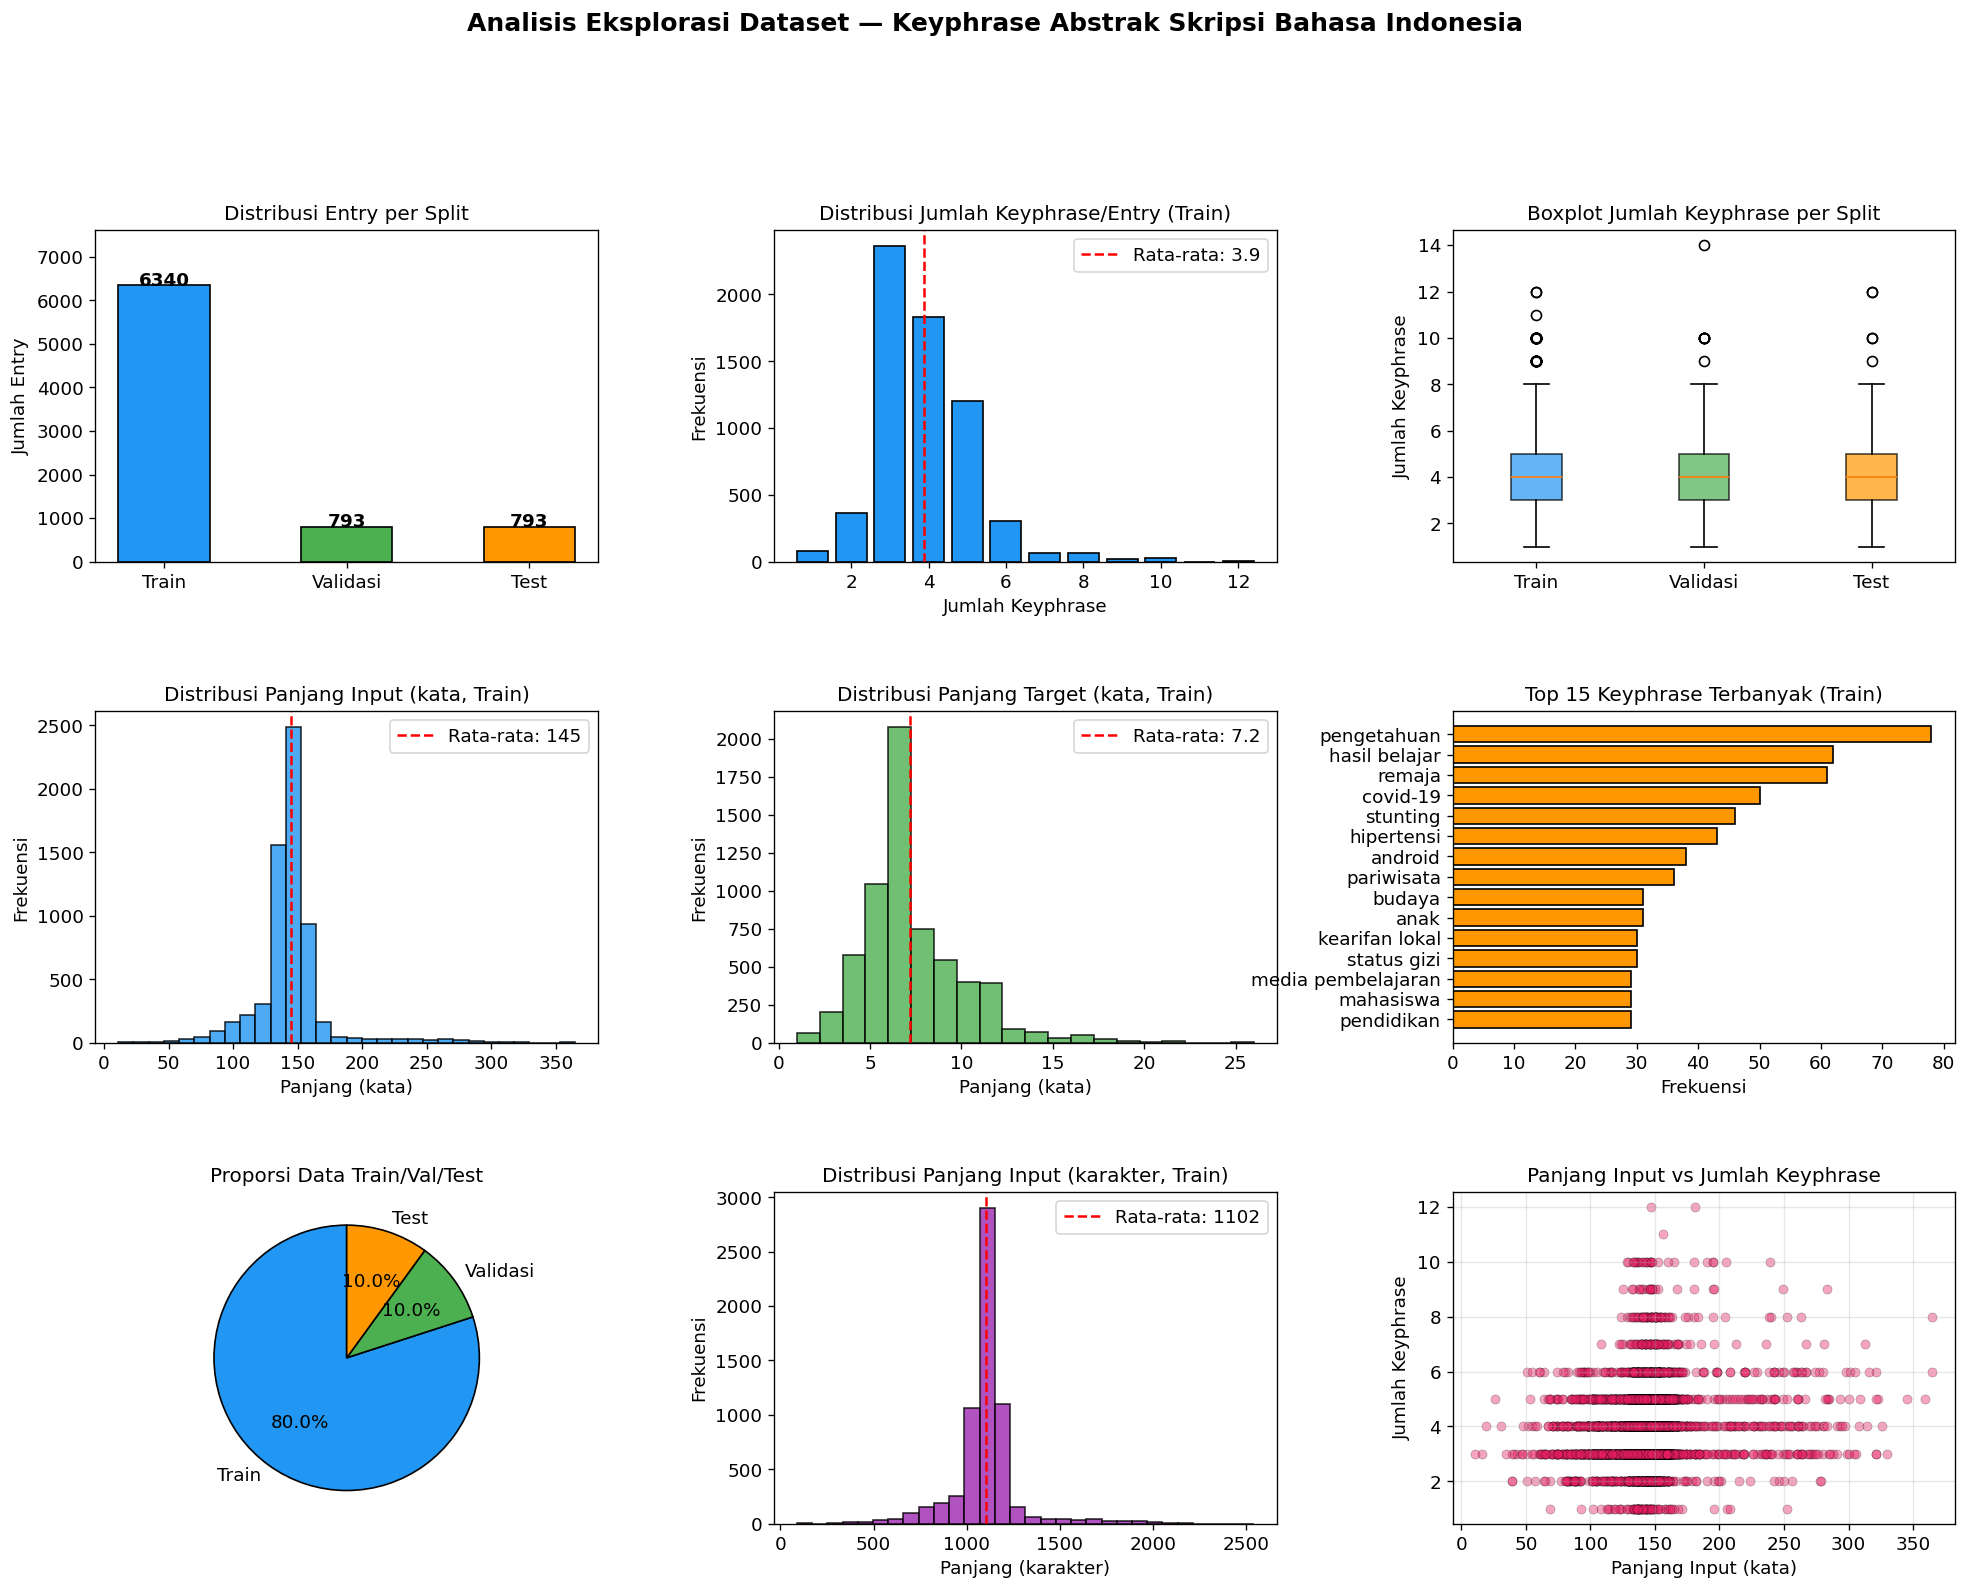

 Plot EDA disimpan.


In [10]:
# ============================================================
# VISUALISASI EDA — 8 PLOT
# ============================================================
split_names  = ['Train', 'Validasi', 'Test']
split_counts = [len(df_train), len(df_val), len(df_test)]
warna        = ['#2196F3', '#4CAF50', '#FF9800']

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Analisis Eksplorasi Dataset — Keyphrase Abstrak Skripsi Bahasa Indonesia',
             fontsize=15, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1 — Distribusi entry per split
ax = fig.add_subplot(gs[0, 0])
bars = ax.bar(split_names, split_counts, color=warna, edgecolor='black', width=0.5)
for b, c in zip(bars, split_counts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, str(c),
            ha='center', fontweight='bold')
ax.set_title('Distribusi Entry per Split'); ax.set_ylabel('Jumlah Entry')
ax.set_ylim(0, max(split_counts)*1.2)

# Plot 2 — Distribusi jumlah keyphrase per entry (Train)
ax = fig.add_subplot(gs[0, 1])
kp_c = df_train_s['jumlah_keyphrase'].value_counts().sort_index()
ax.bar(kp_c.index, kp_c.values, color='#2196F3', edgecolor='black')
ax.axvline(df_train_s['jumlah_keyphrase'].mean(), color='red', linestyle='--',
           label=f"Rata-rata: {df_train_s['jumlah_keyphrase'].mean():.1f}")
ax.set_title('Distribusi Jumlah Keyphrase/Entry (Train)')
ax.set_xlabel('Jumlah Keyphrase'); ax.set_ylabel('Frekuensi'); ax.legend()

# Plot 3 — Boxplot jumlah keyphrase antar split
ax = fig.add_subplot(gs[0, 2])
bp = ax.boxplot([df_train_s['jumlah_keyphrase'],
                 df_val_s['jumlah_keyphrase'],
                 df_test_s['jumlah_keyphrase']],
                labels=split_names, patch_artist=True)
for patch, c in zip(bp['boxes'], warna):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_title('Boxplot Jumlah Keyphrase per Split'); ax.set_ylabel('Jumlah Keyphrase')

# Plot 4 — Distribusi panjang input
ax = fig.add_subplot(gs[1, 0])
ax.hist(df_train_s['panjang_input'], bins=30, color='#2196F3', edgecolor='black', alpha=0.8)
ax.axvline(df_train_s['panjang_input'].mean(), color='red', linestyle='--',
           label=f"Rata-rata: {df_train_s['panjang_input'].mean():.0f}")
ax.set_title('Distribusi Panjang Input (kata, Train)')
ax.set_xlabel('Panjang (kata)'); ax.set_ylabel('Frekuensi'); ax.legend()

# Plot 5 — Distribusi panjang target
ax = fig.add_subplot(gs[1, 1])
ax.hist(df_train_s['panjang_target'], bins=20, color='#4CAF50', edgecolor='black', alpha=0.8)
ax.axvline(df_train_s['panjang_target'].mean(), color='red', linestyle='--',
           label=f"Rata-rata: {df_train_s['panjang_target'].mean():.1f}")
ax.set_title('Distribusi Panjang Target (kata, Train)')
ax.set_xlabel('Panjang (kata)'); ax.set_ylabel('Frekuensi'); ax.legend()

# Plot 6 — Top 15 keyphrase
ax = fig.add_subplot(gs[1, 2])
semua_kp = [kp.strip().lower()
            for s in df_train['target_model'].astype(str)
            for kp in s.split(',')]
top_kp = Counter(semua_kp).most_common(15)
ax.barh([x[0][:22] for x in top_kp][::-1],
        [x[1] for x in top_kp][::-1],
        color='#FF9800', edgecolor='black')
ax.set_title('Top 15 Keyphrase Terbanyak (Train)')
ax.set_xlabel('Frekuensi')

# Plot 7 — Pie proporsi split
ax = fig.add_subplot(gs[2, 0])
ax.pie(split_counts, labels=split_names, colors=warna, autopct='%1.1f%%',
       startangle=90, wedgeprops={'edgecolor':'black'})
ax.set_title('Proporsi Data Train/Val/Test')

# Plot 8 — Distribusi karakter input
ax = fig.add_subplot(gs[2, 1])
ax.hist(df_train_s['char_input'], bins=30, color='#9C27B0', edgecolor='black', alpha=0.8)
ax.axvline(df_train_s['char_input'].mean(), color='red', linestyle='--',
           label=f"Rata-rata: {df_train_s['char_input'].mean():.0f}")
ax.set_title('Distribusi Panjang Input (karakter, Train)')
ax.set_xlabel('Panjang (karakter)'); ax.set_ylabel('Frekuensi'); ax.legend()

# Plot 9 — Scatter panjang input vs jumlah keyphrase
ax = fig.add_subplot(gs[2, 2])
ax.scatter(df_train_s['panjang_input'], df_train_s['jumlah_keyphrase'],
           alpha=0.4, color='#E91E63', edgecolors='black', linewidths=0.3, s=30)
ax.set_title('Panjang Input vs Jumlah Keyphrase')
ax.set_xlabel('Panjang Input (kata)'); ax.set_ylabel('Jumlah Keyphrase')
ax.grid(alpha=0.3)

plt.savefig(os.path.join(RESULTS_DIR, 'eda_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Plot EDA disimpan.")

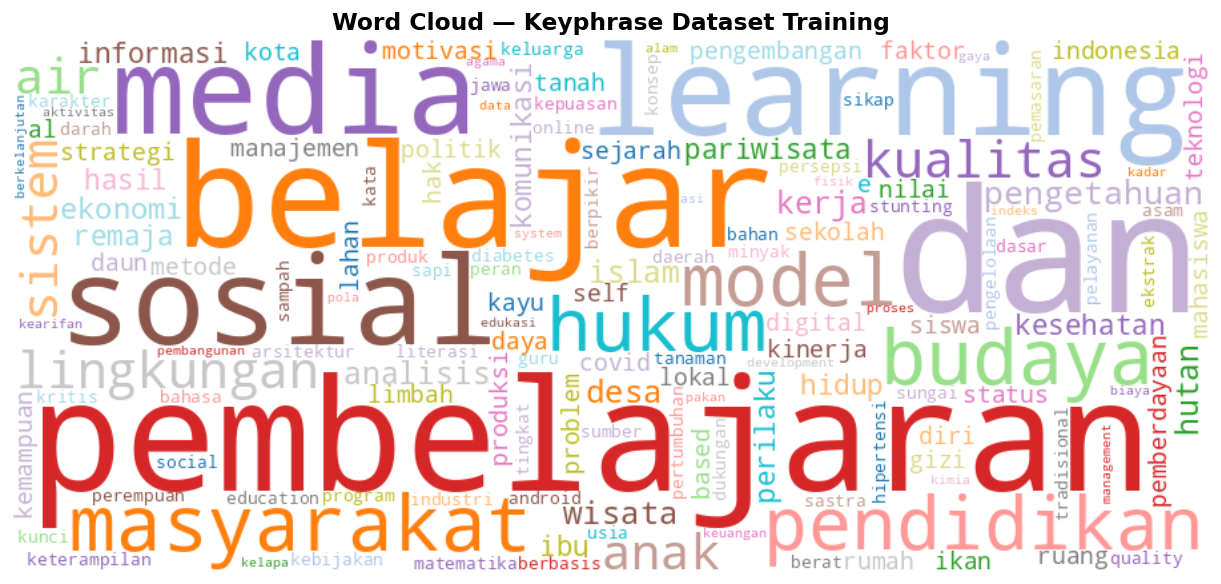

 Word cloud disimpan.


In [11]:
# ============================================================
# WORD CLOUD — Keyphrase Train
# ============================================================
semua_kp_text = ' '.join(semua_kp)
wc = WordCloud(width=900, height=400, background_color='white',
               colormap='tab20', max_words=150,
               collocations=False).generate(semua_kp_text)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — Keyphrase Dataset Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'wordcloud_keyphrase.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Word cloud disimpan.")

##  BAGIAN 7: Tokenizer & Tokenisasi Dataset

In [12]:
print(f"Memuat tokenizer '{MODEL_NAME}'...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

print(f" Tokenizer dimuat.")
print(f"   Vocabulary size : {tokenizer.vocab_size:,}")
print(f"   Pad token       : '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")
print(f"   EOS token       : '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")

# Uji tokenisasi
ex_in  = df_train.iloc[0]['input_model']
ex_tgt = df_train.iloc[0]['target_model']
tok_in  = tokenizer(ex_in,  max_length=MAX_INPUT_LEN,  truncation=True)
tok_tgt = tokenizer(ex_tgt, max_length=MAX_TARGET_LEN, truncation=True)
print(f"\nUji tokenisasi:")
print(f"   Input (kata)  → token : {len(ex_in.split())} kata → {len(tok_in['input_ids'])} token")
print(f"   Target        → token : {len(tok_tgt['input_ids'])} token")

Memuat tokenizer 't5-small'...


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

 Tokenizer dimuat.
   Vocabulary size : 32,100
   Pad token       : '<pad>' (id=0)
   EOS token       : '</s>' (id=1)

Uji tokenisasi:
   Input (kata)  → token : 133 kata → 494 token
   Target        → token : 9 token


In [13]:
def tokenisasi_data(contoh):
    hasil_input = tokenizer(
        contoh['input_model'],
        max_length=MAX_INPUT_LEN, truncation=True, padding=False
    )
    hasil_target = tokenizer(
        contoh['target_model'],
        max_length=MAX_TARGET_LEN, truncation=True, padding=False
    )
    hasil_input['labels'] = hasil_target['input_ids']
    return hasil_input

print("Mengkonversi DataFrame → HuggingFace Dataset...")
hf_train = HFDataset.from_pandas(df_train[['input_model','target_model']].reset_index(drop=True))
hf_val   = HFDataset.from_pandas(df_val[['input_model','target_model']].reset_index(drop=True))
hf_test  = HFDataset.from_pandas(df_test[['input_model','target_model']].reset_index(drop=True))

print("Tokenisasi dataset...")
tokenized_train = hf_train.map(tokenisasi_data, batched=True, remove_columns=['input_model','target_model'])
tokenized_val   = hf_val.map(tokenisasi_data,   batched=True, remove_columns=['input_model','target_model'])
tokenized_test  = hf_test.map(tokenisasi_data,  batched=True, remove_columns=['input_model','target_model'])

pjg_train  = [len(x) for x in tokenized_train['input_ids']]
pjg_target = [len(x) for x in tokenized_train['labels']]
print(f"\n Tokenisasi selesai.")
print(f"   Train  : {len(tokenized_train)} sampel | Rata-rata token input: {np.mean(pjg_train):.1f}")
print(f"   Val    : {len(tokenized_val)} sampel")
print(f"   Test   : {len(tokenized_test)} sampel")
print(f"   Token target rata-rata : {np.mean(pjg_target):.1f} | maks: {max(pjg_target)}")

Mengkonversi DataFrame → HuggingFace Dataset...
Tokenisasi dataset...


Map:   0%|          | 0/6340 [00:00<?, ? examples/s]

Map:   0%|          | 0/793 [00:00<?, ? examples/s]

Map:   0%|          | 0/793 [00:00<?, ? examples/s]


 Tokenisasi selesai.
   Train  : 6340 sampel | Rata-rata token input: 490.0
   Val    : 793 sampel
   Test   : 793 sampel
   Token target rata-rata : 26.5 | maks: 64


##  BAGIAN 8: Inisialisasi Model T5

In [14]:
print(f"Memuat model '{MODEL_NAME}'...")
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Model dimuat.")
print(f"{'='*45}")
print(f"  Total parameter    : {total_p:,}")
print(f"  Parameter trainable: {trainable_p:,} ({100*trainable_p/total_p:.1f}%)")
print(f"  Device             : {next(model.parameters()).device}")
print(f"  d_model            : {model.config.d_model}")
print(f"  Encoder layers     : {model.config.num_layers}")
print(f"  Attention heads    : {model.config.num_heads}")
print(f"  Feed-forward dim   : {model.config.d_ff}")
print(f"{'='*45}")

Memuat model 't5-small'...


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


 Model dimuat.
  Total parameter    : 60,506,624
  Parameter trainable: 60,506,624 (100.0%)
  Device             : cuda:0
  d_model            : 512
  Encoder layers     : 6
  Attention heads    : 8
  Feed-forward dim   : 2048


##  BAGIAN 9: Metrik Evaluasi (ROUGE + BLEU)

In [15]:
rouge_metric = evaluate.load('rouge')
bleu_metric  = evaluate.load('sacrebleu')

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, torch.Tensor):
        predictions = predictions.cpu().numpy()
    predictions = np.where(predictions < 0, tokenizer.pad_token_id, predictions)
    decoded_preds  = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels         = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels,      skip_special_tokens=True)
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    rouge = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=False
    )
    # BLEU
    bleu = bleu_metric.compute(
        predictions=decoded_preds,
        references=[[l] for l in decoded_labels]
    )
    return {
        'rouge1' : round(rouge['rouge1'] * 100, 4),
        'rouge2' : round(rouge['rouge2'] * 100, 4),
        'rougeL' : round(rouge['rougeL'] * 100, 4),
        'bleu'   : round(bleu['score'],  4),
    }

print(" Metrik evaluasi: ROUGE-1, ROUGE-2, ROUGE-L, BLEU")

 Metrik evaluasi: ROUGE-1, ROUGE-2, ROUGE-L, BLEU


## ️ BAGIAN 10: Konfigurasi Trainer & Fine-Tuning

In [16]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, model=model,
    label_pad_token_id=-100, pad_to_multiple_of=8
)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=MAX_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH,
    per_device_eval_batch_size=EVAL_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type='linear',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=NUM_BEAMS,
    logging_dir=LOG_DIR,
    logging_strategy='epoch',
    report_to='none',
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    seed=SEED, data_seed=SEED,
    push_to_hub=PUSH_TO_HUB,
    hub_model_id=HF_REPO_NAME if PUSH_TO_HUB else None,
)

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=ES_PATIENCE,
    early_stopping_threshold=0.001
)

trainer = Seq2SeqTrainer(
    model=model, args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

steps_per_epoch = math.ceil(len(tokenized_train) / (TRAIN_BATCH * GRAD_ACCUM))
total_steps     = steps_per_epoch * MAX_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print(" Trainer siap.")
print(f"   Train samples  : {len(tokenized_train)}")
print(f"   Val samples    : {len(tokenized_val)}")
print(f"   Steps/epoch    : {steps_per_epoch}")
print(f"   Total steps    : {total_steps} (maks)")
print(f"   Warmup steps   : {warmup_steps}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


 Trainer siap.
   Train samples  : 6340
   Val samples    : 793
   Steps/epoch    : 793
   Total steps    : 7930 (maks)
   Warmup steps   : 793


In [17]:
print("="*55)
print("  MEMULAI FINE-TUNING T5-SMALL")
print("="*55)
t0 = time.time()
hasil_training = trainer.train()
durasi = time.time() - t0

print("\n" + "="*55)
print("  TRAINING SELESAI")
print("="*55)
print(f"  Waktu training     : {durasi/60:.1f} menit")
print(f"  Total step (aktual): {hasil_training.global_step}")
print(f"  Training loss akhir: {hasil_training.training_loss:.4f}")

  MEMULAI FINE-TUNING T5-SMALL


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu
1,2.142751,1.684176,31.577600,15.742400,27.827400,12.405300
2,1.746681,1.586428,36.525000,18.566700,31.912800,16.029900
3,1.643337,1.541845,37.975000,19.416000,32.991800,16.833900
4,1.585784,1.515839,39.033300,20.253300,34.164400,18.090900
5,1.545540,1.500843,39.808800,20.691500,34.662500,18.653400
6,1.508408,1.484927,40.552400,21.347900,35.115900,19.057200
7,1.485947,1.477201,40.212900,21.125400,35.026800,19.080900
8,1.463030,1.481867,40.575600,21.468000,35.343900,19.309600
9,1.447515,1.473557,40.846600,21.468400,35.496300,19.359000
10,1.443425,1.473279,41.025900,21.517000,35.320000,19.116600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



  TRAINING SELESAI
  Waktu training     : 44.3 menit
  Total step (aktual): 7930
  Training loss akhir: 1.6012


##  BAGIAN 11: Simpan Model Terbaik

In [26]:
import os
import json
from huggingface_hub import login, get_token # Ensure get_token is imported directly
from google.colab import userdata # Ensure userdata is imported

print(f"Menyimpan model ke: {OUTPUT_DIR}")

# Check and attempt login to Hugging Face Hub if PUSH_TO_HUB is True
if PUSH_TO_HUB:
    print("Mencoba login ke Hugging Face Hub...")
    hf_token = getattr(userdata, 'HF_TOKEN', None) # Get token from Colab Secrets

    login_successful = False
    try:
        if hf_token:
            login(token=hf_token, add_to_git_credential=True)
            print("Berhasil login menggunakan Colab Secret 'HF_TOKEN'.")
            login_successful = True
        else:
            print("Colab Secret 'HF_TOKEN' tidak ditemukan. Mencoba login interaktif.")
            # This interactive login call might prompt the user. In a non-interactive run, it might fail or not set a token.
            login(add_to_git_credential=True) # Will prompt for login if not already logged in
            if get_token(): # Check if a token is now available after interactive attempt
                print("Login interaktif berhasil.")
                login_successful = True
            else:
                print("Login interaktif tidak berhasil atau dilewati. Tidak dapat push ke HF Hub.")

    except Exception as e:
        print(f"Gagal saat mencoba login ke Hugging Face Hub: {e}")

    if not login_successful:
        print("Pushing ke Hugging Face Hub dinonaktifkan karena login tidak berhasil.")
        trainer.args.push_to_hub = False # Disable push in trainer arguments

# Now save the model. trainer.save_model will respect trainer.args.push_to_hub
# If trainer.args.push_to_hub is True, it will attempt to push. If False, it will only save locally.
try:
    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR) # tokenizer.save_pretrained will also respect trainer.args.push_to_hub implicitly if used with Trainer
    print(" Model berhasil disimpan.") # This message implies success, whether locally or pushed
except Exception as e:
    print(f"Terjadi kesalahan saat menyimpan model: {e}")
    print("Pastikan token Hugging Face Anda valid dan repository ada jika mencoba push.")

config_info = {
    'model_name': MODEL_NAME, 'learning_rate': LEARNING_RATE,
    'train_batch': TRAIN_BATCH, 'max_epochs': MAX_EPOCHS,
    'max_input_len': MAX_INPUT_LEN, 'max_target_len': MAX_TARGET_LEN,
    'es_patience': ES_PATIENCE, 'num_beams': NUM_BEAMS, 'seed': SEED,
    'train_samples': len(tokenized_train), 'val_samples': len(tokenized_val),
    'test_samples': len(tokenized_test),
    'total_steps': hasil_training.global_step,
    'training_loss': hasil_training.training_loss,
    'training_time_minutes': round(durasi/60, 2)
}
with open(os.path.join(OUTPUT_DIR, 'training_config.json'), 'w', encoding='utf-8') as f:
    json.dump(config_info, f, indent=2, ensure_ascii=False)

print("\nIsi direktori output:")
for item in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, item))
    print(f"   {item:<40} ({sz/1024:.1f} KB)")

Menyimpan model ke: /content/model_t5_keyphrase
Mencoba login ke Hugging Face Hub...
Colab Secret 'HF_TOKEN' tidak ditemukan. Mencoba login interaktif.
Login interaktif berhasil.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...yphrase/model.safetensors:   0%|          |  552kB /  242MB            

  ...yphrase/training_args.bin:   9%|9         |   509B / 5.39kB            

 Model berhasil disimpan.

Isi direktori output:
   README.md                                (2.4 KB)
   checkpoint-7137                          (4.0 KB)
   checkpoint-7930                          (4.0 KB)
   config.json                              (1.5 KB)
   generation_config.json                   (0.9 KB)
   model.safetensors                        (236369.0 KB)
   tokenizer.json                           (2367.3 KB)
   tokenizer_config.json                    (2.3 KB)
   training_args.bin                        (5.3 KB)
   training_config.json                     (0.4 KB)


##  BAGIAN 12: Visualisasi Training Curves

In [27]:
log_history  = trainer.state.log_history
train_logs   = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs    = [l for l in log_history if 'eval_loss' in l]
df_train_log = pd.DataFrame(train_logs)
df_eval_log  = pd.DataFrame(eval_logs)

print("Log training:")
cols = [c for c in ['epoch','eval_loss','eval_rouge1','eval_rouge2','eval_rougeL','eval_bleu']
        if c in df_eval_log.columns]
print(df_eval_log[cols].to_string(index=False))

Log training:
 epoch  eval_loss  eval_rouge1  eval_rouge2  eval_rougeL  eval_bleu
   1.0   1.684176      31.5776      15.7424      27.8274    12.4053
   2.0   1.586428      36.5250      18.5667      31.9128    16.0299
   3.0   1.541845      37.9750      19.4160      32.9918    16.8339
   4.0   1.515839      39.0333      20.2533      34.1644    18.0909
   5.0   1.500843      39.8088      20.6915      34.6625    18.6534
   6.0   1.484927      40.5524      21.3479      35.1159    19.0572
   7.0   1.477201      40.2129      21.1254      35.0268    19.0809
   8.0   1.481867      40.5756      21.4680      35.3439    19.3096
   9.0   1.473557      40.8466      21.4684      35.4963    19.3590
  10.0   1.473279      41.0259      21.5170      35.3200    19.1166


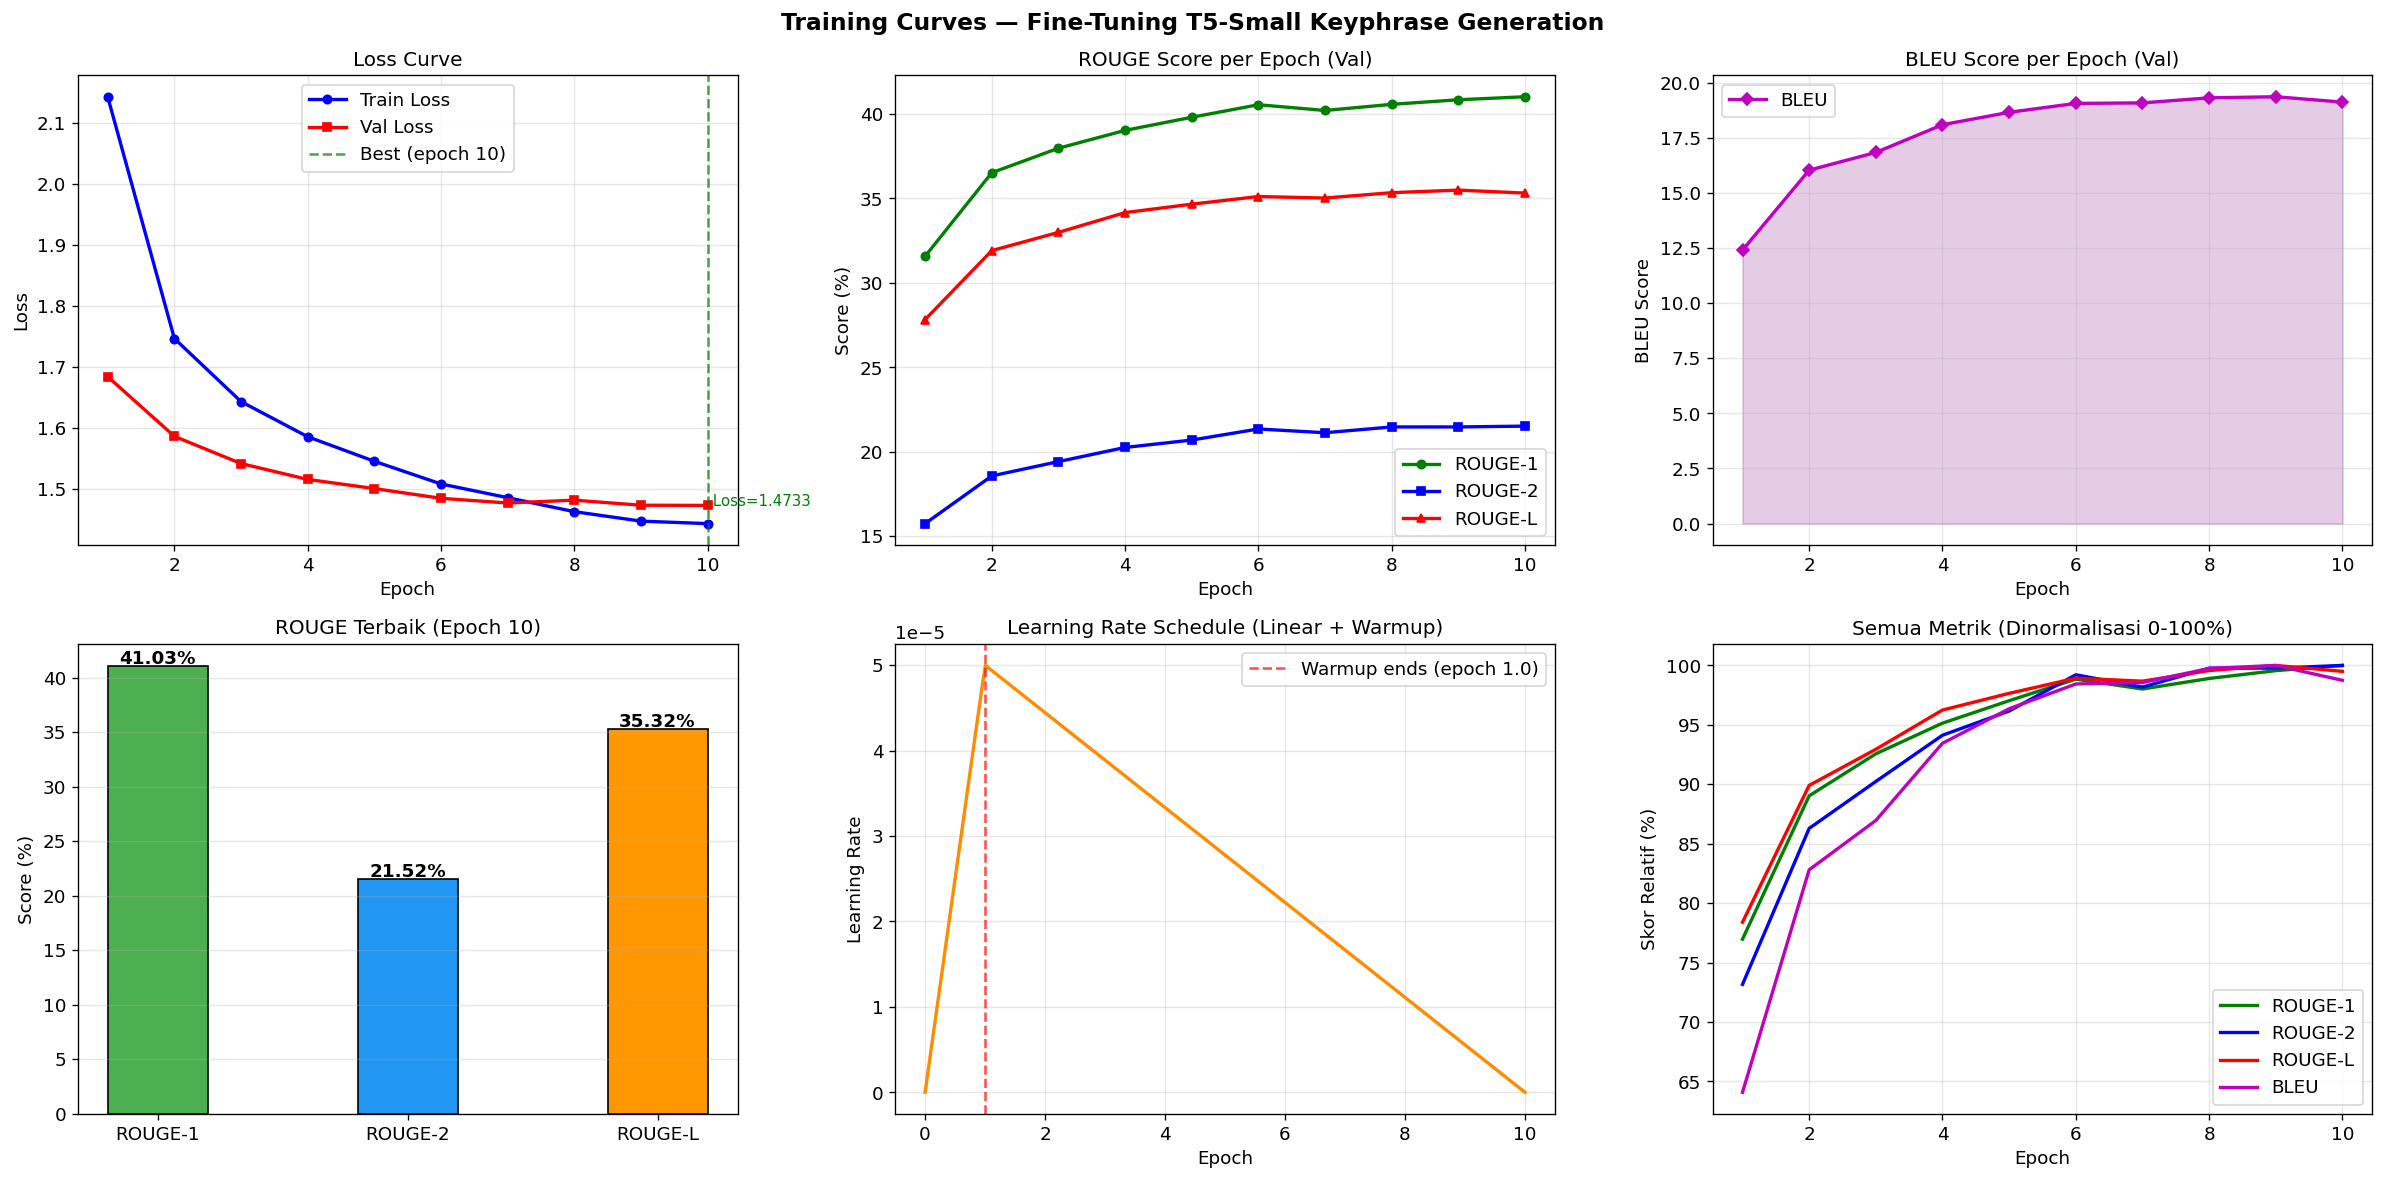

 Training curves disimpan.


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Training Curves — Fine-Tuning T5-Small Keyphrase Generation',
             fontsize=14, fontweight='bold')

ep_tr = df_train_log['epoch'].values if 'epoch' in df_train_log.columns else []
ep_ev = df_eval_log['epoch'].values  if 'epoch' in df_eval_log.columns  else []

# 1 — Loss curve
ax = axes[0,0]
if len(ep_tr)>0 and 'loss' in df_train_log.columns:
    ax.plot(ep_tr, df_train_log['loss'], 'b-o', ms=5, lw=2, label='Train Loss')
if len(ep_ev)>0 and 'eval_loss' in df_eval_log.columns:
    ax.plot(ep_ev, df_eval_log['eval_loss'], 'r-s', ms=5, lw=2, label='Val Loss')
    idx_b = df_eval_log['eval_loss'].idxmin()
    be, bl = df_eval_log.loc[idx_b,'epoch'], df_eval_log.loc[idx_b,'eval_loss']
    ax.axvline(be, color='green', ls='--', alpha=0.7, label=f'Best (epoch {be:.0f})')
    ax.annotate(f' Loss={bl:.4f}', xy=(be,bl), fontsize=9, color='green')
ax.set_title('Loss Curve'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# 2 — ROUGE per epoch
ax = axes[0,1]
rouge_cols = {'eval_rouge1':('g-o','ROUGE-1'), 'eval_rouge2':('b-s','ROUGE-2'), 'eval_rougeL':('r-^','ROUGE-L')}
for col,(style,label) in rouge_cols.items():
    if col in df_eval_log.columns:
        ax.plot(ep_ev, df_eval_log[col], style, ms=5, lw=2, label=label)
ax.set_title('ROUGE Score per Epoch (Val)'); ax.set_xlabel('Epoch')
ax.set_ylabel('Score (%)'); ax.legend(); ax.grid(alpha=0.3)

# 3 — BLEU per epoch
ax = axes[0,2]
if 'eval_bleu' in df_eval_log.columns:
    ax.plot(ep_ev, df_eval_log['eval_bleu'], 'm-D', ms=5, lw=2, label='BLEU')
    ax.fill_between(ep_ev, df_eval_log['eval_bleu'], alpha=0.2, color='purple')
ax.set_title('BLEU Score per Epoch (Val)'); ax.set_xlabel('Epoch')
ax.set_ylabel('BLEU Score'); ax.legend(); ax.grid(alpha=0.3)

# 4 — Bar ROUGE terbaik
ax = axes[1,0]
if len(df_eval_log)>0:
    best_row  = df_eval_log.loc[df_eval_log['eval_loss'].idxmin()]
    mn  = ['ROUGE-1','ROUGE-2','ROUGE-L']
    mv  = [best_row.get('eval_rouge1',0), best_row.get('eval_rouge2',0), best_row.get('eval_rougeL',0)]
    mcl = ['#4CAF50','#2196F3','#FF9800']
    bars = ax.bar(mn, mv, color=mcl, edgecolor='black', width=0.4)
    for b, v in zip(bars, mv):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                f'{v:.2f}%', ha='center', fontweight='bold')
    ax.set_title(f'ROUGE Terbaik (Epoch {best_row["epoch"]:.0f})')
    ax.set_ylabel('Score (%)'); ax.grid(axis='y', alpha=0.3)

# 5 — Learning rate schedule (simulasi)
ax = axes[1,1]
n_ep = len(ep_ev) if len(ep_ev)>0 else MAX_EPOCHS
x_steps = np.linspace(0, n_ep, 200)
wm = WARMUP_RATIO * n_ep
lr_sim = np.where(x_steps < wm,
                  LEARNING_RATE * (x_steps/wm),
                  LEARNING_RATE * (1 - (x_steps - wm)/(n_ep - wm)))
ax.plot(x_steps, lr_sim, 'darkorange', lw=2)
ax.axvline(wm, color='red', ls='--', alpha=0.7, label=f'Warmup ends (epoch {wm:.1f})')
ax.set_title('Learning Rate Schedule (Linear + Warmup)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.legend(); ax.grid(alpha=0.3)

# 6 — Gabungan semua metrik normalisasi
ax = axes[1,2]
if len(df_eval_log)>0:
    for col, lbl, col_style in [
        ('eval_rouge1','ROUGE-1','g'), ('eval_rouge2','ROUGE-2','b'),
        ('eval_rougeL','ROUGE-L','r'), ('eval_bleu','BLEU','m')
    ]:
        if col in df_eval_log.columns:
            vals = df_eval_log[col].values
            ax.plot(ep_ev, vals/vals.max()*100, f'{col_style}-',
                    ms=4, lw=2, label=lbl)
ax.set_title('Semua Metrik (Dinormalisasi 0-100%)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Skor Relatif (%)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Training curves disimpan.")

##  BAGIAN 13: Evaluasi Model pada Data Test

In [29]:
print("Menjalankan evaluasi pada data test...")
hasil_test = trainer.predict(
    tokenized_test,
    metric_key_prefix='test',
    max_length=MAX_TARGET_LEN,
    num_beams=NUM_BEAMS,
    no_repeat_ngram_size=NO_REPEAT_NGRAM,
    length_penalty=LENGTH_PENALTY,
)

pred_ids   = np.where(hasil_test.predictions < 0, tokenizer.pad_token_id, hasil_test.predictions)
label_ids  = np.where(hasil_test.label_ids != -100, hasil_test.label_ids, tokenizer.pad_token_id)

prediksi_teks  = [p.strip() for p in tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)]
referensi_teks = [r.strip() for r in tokenizer.batch_decode(label_ids, skip_special_tokens=True)]

# ROUGE
hasil_rouge = rouge_metric.compute(
    predictions=prediksi_teks, references=referensi_teks, use_stemmer=False
)
# BLEU
hasil_bleu = bleu_metric.compute(
    predictions=prediksi_teks, references=[[r] for r in referensi_teks]
)

print("\n" + "="*55)
print("  HASIL EVALUASI TEST SET — T5-Small Fine-Tuned")
print("="*55)
print(f"  Jumlah sampel test : {len(prediksi_teks)}")
print(f"  ROUGE-1            : {hasil_rouge['rouge1']*100:.4f}%")
print(f"  ROUGE-2            : {hasil_rouge['rouge2']*100:.4f}%")
print(f"  ROUGE-L            : {hasil_rouge['rougeL']*100:.4f}%")
print(f"  BLEU               : {hasil_bleu['score']:.4f}")
print("="*55)

metrik_t5 = {
    'rouge1': round(hasil_rouge['rouge1']*100, 4),
    'rouge2': round(hasil_rouge['rouge2']*100, 4),
    'rougeL': round(hasil_rouge['rougeL']*100, 4),
    'bleu'  : round(hasil_bleu['score'], 4),
    'n_sampel': len(prediksi_teks)
}
with open(os.path.join(RESULTS_DIR, 'test_metrics_t5.json'), 'w') as f:
    json.dump(metrik_t5, f, indent=2)
print(" Metrik test T5 disimpan.")

Menjalankan evaluasi pada data test...



  HASIL EVALUASI TEST SET — T5-Small Fine-Tuned
  Jumlah sampel test : 793
  ROUGE-1            : 40.4601%
  ROUGE-2            : 20.3277%
  ROUGE-L            : 34.4598%
  BLEU               : 17.7187
 Metrik test T5 disimpan.


##  BAGIAN 14: Exact Match & Keyphrase-Level Metrics

In [30]:
print("Menghitung keyphrase-level metrics (Exact Match)...")

total_tp = total_fp = total_fn = 0
exact_match_count = 0

for pred, ref in zip(prediksi_teks, referensi_teks):
    set_pred = {k.strip().lower() for k in str(pred).split(',') if k.strip()}
    set_ref  = {k.strip().lower() for k in str(ref).split(',')  if k.strip()}
    tp = len(set_pred & set_ref)
    fp = len(set_pred - set_ref)
    fn = len(set_ref  - set_pred)
    total_tp += tp; total_fp += fp; total_fn += fn
    if set_pred == set_ref:
        exact_match_count += 1

prec_em = total_tp/(total_tp+total_fp) if (total_tp+total_fp)>0 else 0
rec_em  = total_tp/(total_tp+total_fn) if (total_tp+total_fn)>0 else 0
f1_em   = 2*prec_em*rec_em/(prec_em+rec_em) if (prec_em+rec_em)>0 else 0
em_pct  = exact_match_count/len(prediksi_teks)*100

print("\n" + "="*55)
print("  KEYPHRASE EXACT MATCH METRICS — T5-Small")
print("="*55)
print(f"  Precision (Micro)  : {prec_em*100:.4f}%")
print(f"  Recall    (Micro)  : {rec_em*100:.4f}%")
print(f"  F1 Score  (Micro)  : {f1_em*100:.4f}%")
print(f"  Exact Match (%)    : {em_pct:.2f}%  ({exact_match_count}/{len(prediksi_teks)})")
print(f"  TP / FP / FN       : {total_tp} / {total_fp} / {total_fn}")
print("="*55)

clf_t5 = {
    'precision': round(prec_em*100,4), 'recall': round(rec_em*100,4),
    'f1_score' : round(f1_em*100,4),   'exact_match_pct': round(em_pct,4),
    'tp': int(total_tp), 'fp': int(total_fp), 'fn': int(total_fn)
}
with open(os.path.join(RESULTS_DIR, 'clf_report_t5.json'), 'w') as f:
    json.dump(clf_t5, f, indent=2)
print(" Laporan classification T5 disimpan.")

Menghitung keyphrase-level metrics (Exact Match)...

  KEYPHRASE EXACT MATCH METRICS — T5-Small
  Precision (Micro)  : 21.7589%
  Recall    (Micro)  : 16.9617%
  F1 Score  (Micro)  : 19.0631%
  Exact Match (%)    : 0.50%  (4/793)
  TP / FP / FN       : 527 / 1895 / 2580
 Laporan classification T5 disimpan.


##  BAGIAN 15: Analisis Kualitas Prediksi Per Sampel

In [31]:
print("Menghitung ROUGE per sampel...")
skor_ps = []
for i, (pred, ref) in enumerate(zip(prediksi_teks, referensi_teks)):
    sk = rouge_metric.compute(predictions=[pred], references=[ref], use_stemmer=False)
    set_p = {k.strip().lower() for k in str(pred).split(',') if k.strip()}
    set_r = {k.strip().lower() for k in str(ref).split(',')  if k.strip()}
    tp_i  = len(set_p & set_r)
    pr_i  = tp_i/len(set_p) if set_p else 0
    rc_i  = tp_i/len(set_r) if set_r else 0
    f1_i  = 2*pr_i*rc_i/(pr_i+rc_i) if (pr_i+rc_i)>0 else 0
    skor_ps.append({
        'rouge1': sk['rouge1']*100, 'rouge2': sk['rouge2']*100,
        'rougeL': sk['rougeL']*100, 'f1_em': f1_i*100,
        'n_pred_kp': len(set_p), 'n_ref_kp': len(set_r),
        'prediksi': pred, 'referensi': ref,
        'input': df_test.iloc[i]['input_model'][:120]+'...'
    })

df_skor = pd.DataFrame(skor_ps)

print("\nStatistik ROUGE per sampel (Test):")
for m in ['rouge1','rouge2','rougeL','f1_em']:
    print(f"  {m:<8}: mean={df_skor[m].mean():.2f}% | "
          f"median={df_skor[m].median():.2f}% | "
          f"std={df_skor[m].std():.2f}% | "
          f"min={df_skor[m].min():.2f}% | max={df_skor[m].max():.2f}%")

# Top 5 & Bottom 5
print("\n" + "="*65)
print("  TOP 5 PREDIKSI TERBAIK (ROUGE-L tertinggi):")
print("="*65)
for i, (_, r) in enumerate(df_skor.nlargest(5,'rougeL').iterrows(), 1):
    print(f"\n  [Rank {i}] ROUGE-L: {r['rougeL']:.2f}%")
    print(f"    Ref  : {r['referensi']}")
    print(f"    Pred : {r['prediksi']}")

print("\n" + "="*65)
print("  5 PREDIKSI TERBURUK (ROUGE-L terendah):")
print("="*65)
for i, (_, r) in enumerate(df_skor.nsmallest(5,'rougeL').iterrows(), 1):
    print(f"\n  [Rank {i}] ROUGE-L: {r['rougeL']:.2f}%")
    print(f"    Ref  : {r['referensi']}")
    print(f"    Pred : {r['prediksi']}")

df_skor.to_csv(os.path.join(RESULTS_DIR, 'per_sample_scores_t5.csv'), index=False)
print("\n Skor per sampel T5 disimpan.")

Menghitung ROUGE per sampel...

Statistik ROUGE per sampel (Test):
  rouge1  : mean=40.49% | median=40.00% | std=24.95% | min=0.00% | max=100.00%
  rouge2  : mean=20.32% | median=16.67% | std=21.49% | min=0.00% | max=100.00%
  rougeL  : mean=34.51% | median=33.33% | std=22.28% | min=0.00% | max=100.00%
  f1_em   : mean=19.00% | median=0.00% | std=23.16% | min=0.00% | max=100.00%

  TOP 5 PREDIKSI TERBAIK (ROUGE-L tertinggi):

  [Rank 1] ROUGE-L: 100.00%
    Ref  : etika profesi, fee audit, kualitas audit
    Pred : etika profesi, fee audit, kualitas audit

  [Rank 2] ROUGE-L: 100.00%
    Ref  : penggunaan handphone, motivasi belajar
    Pred : penggunaan handphone, motivasi belajar

  [Rank 3] ROUGE-L: 100.00%
    Ref  : psychological capital, komitmen organisasi, mahasiswa
    Pred : psychological capital, komitmen organisasi, mahasiswa

  [Rank 4] ROUGE-L: 94.74%
    Ref  : pengaruh, problem-based learning, hasil belajar, matematika, kemampuan berpikir kritis
    Pred : problem-based

##  BAGIAN 16: Baseline RAKE

In [32]:
print("Menjalankan RAKE sebagai baseline...")

try:
    stop_words_id = stopwords.words('indonesian')
except:
    stop_words_id = stopwords.words('english')  # fallback

def rake_extract(teks, n_kp=5):
    """
    Ekstrak keyphrase menggunakan RAKE.
    Membersihkan prefix 'generate keyphrases:' jika ada.
    """
    teks_bersih = teks.replace('generate keyphrases:', '').strip()
    r = Rake(stopwords=stop_words_id, min_length=1, max_length=4)
    r.extract_keywords_from_text(teks_bersih)
    hasil = r.get_ranked_phrases()[:n_kp]
    return ', '.join(hasil) if hasil else ''

print(f"Menjalankan RAKE pada {len(df_test)} sampel test...")
t_rake = time.time()
rake_preds = [rake_extract(row['input_model']) for _, row in df_test.iterrows()]
durasi_rake = time.time() - t_rake

# Evaluasi RAKE
rouge_rake = rouge_metric.compute(
    predictions=rake_preds, references=referensi_teks, use_stemmer=False
)
bleu_rake = bleu_metric.compute(
    predictions=rake_preds, references=[[r] for r in referensi_teks]
)

# Exact match RAKE
tp_rk = fp_rk = fn_rk = em_rk = 0
for pred, ref in zip(rake_preds, referensi_teks):
    sp = {k.strip().lower() for k in str(pred).split(',') if k.strip()}
    sr = {k.strip().lower() for k in str(ref).split(',')  if k.strip()}
    tp_rk += len(sp & sr); fp_rk += len(sp - sr); fn_rk += len(sr - sp)
    if sp == sr: em_rk += 1

pr_rk = tp_rk/(tp_rk+fp_rk) if (tp_rk+fp_rk)>0 else 0
rc_rk = tp_rk/(tp_rk+fn_rk) if (tp_rk+fn_rk)>0 else 0
f1_rk = 2*pr_rk*rc_rk/(pr_rk+rc_rk) if (pr_rk+rc_rk)>0 else 0

metrik_rake = {
    'rouge1': round(rouge_rake['rouge1']*100, 4),
    'rouge2': round(rouge_rake['rouge2']*100, 4),
    'rougeL': round(rouge_rake['rougeL']*100, 4),
    'bleu'  : round(bleu_rake['score'], 4),
    'precision_em': round(pr_rk*100, 4), 'recall_em': round(rc_rk*100, 4),
    'f1_em': round(f1_rk*100, 4), 'exact_match_pct': round(em_rk/len(rake_preds)*100,4),
    'waktu_detik': round(durasi_rake, 2)
}

print("\n" + "="*55)
print("  HASIL EVALUASI TEST SET — RAKE (Baseline)")
print("="*55)
print(f"  ROUGE-1       : {metrik_rake['rouge1']:.4f}%")
print(f"  ROUGE-2       : {metrik_rake['rouge2']:.4f}%")
print(f"  ROUGE-L       : {metrik_rake['rougeL']:.4f}%")
print(f"  BLEU          : {metrik_rake['bleu']:.4f}")
print(f"  Precision(EM) : {metrik_rake['precision_em']:.4f}%")
print(f"  Recall (EM)   : {metrik_rake['recall_em']:.4f}%")
print(f"  F1 Score(EM)  : {metrik_rake['f1_em']:.4f}%")
print(f"  Waktu inferensi: {durasi_rake:.2f} detik")
print("="*55)

with open(os.path.join(RESULTS_DIR, 'test_metrics_rake.json'), 'w') as f:
    json.dump(metrik_rake, f, indent=2)
print(" Metrik RAKE disimpan.")

Menjalankan RAKE sebagai baseline...
Menjalankan RAKE pada 793 sampel test...

  HASIL EVALUASI TEST SET — RAKE (Baseline)
  ROUGE-1       : 19.5857%
  ROUGE-2       : 8.5551%
  ROUGE-L       : 16.6206%
  BLEU          : 4.8287
  Precision(EM) : 1.6017%
  Recall (EM)   : 1.9955%
  F1 Score(EM)  : 1.7770%
  Waktu inferensi: 0.76 detik
 Metrik RAKE disimpan.


## ️ BAGIAN 17: Perbandingan T5 vs RAKE

In [33]:
print("="*65)
print("  TABEL PERBANDINGAN: T5-Small Fine-Tuned vs RAKE Baseline")
print("="*65)
tabel_comp = pd.DataFrame({
    'Metrik'   : ['ROUGE-1','ROUGE-2','ROUGE-L','BLEU','Precision(EM)','Recall(EM)','F1(EM)','Exact Match(%)'],
    'T5-Small' : [
        f"{metrik_t5['rouge1']:.4f}%",   f"{metrik_t5['rouge2']:.4f}%",
        f"{metrik_t5['rougeL']:.4f}%",   f"{metrik_t5['bleu']:.4f}",
        f"{clf_t5['precision']:.4f}%",    f"{clf_t5['recall']:.4f}%",
        f"{clf_t5['f1_score']:.4f}%",     f"{clf_t5['exact_match_pct']:.2f}%"
    ],
    'RAKE (Baseline)': [
        f"{metrik_rake['rouge1']:.4f}%",      f"{metrik_rake['rouge2']:.4f}%",
        f"{metrik_rake['rougeL']:.4f}%",      f"{metrik_rake['bleu']:.4f}",
        f"{metrik_rake['precision_em']:.4f}%",f"{metrik_rake['recall_em']:.4f}%",
        f"{metrik_rake['f1_em']:.4f}%",       f"{metrik_rake['exact_match_pct']:.2f}%"
    ]
})

def delta(t5_v, rake_v):
    try:
        d = float(str(t5_v).replace('%','')) - float(str(rake_v).replace('%',''))
        return f"+{d:.4f}" if d >= 0 else f"{d:.4f}"
    except: return '-'

tabel_comp['Delta (T5 - RAKE)'] = [
    delta(t, r) for t, r in zip(tabel_comp['T5-Small'], tabel_comp['RAKE (Baseline)'])
]
print(tabel_comp.to_string(index=False))
tabel_comp.to_csv(os.path.join(RESULTS_DIR, 'comparison_t5_vs_rake.csv'), index=False)
print("\n Tabel perbandingan disimpan.")

  TABEL PERBANDINGAN: T5-Small Fine-Tuned vs RAKE Baseline
        Metrik T5-Small RAKE (Baseline) Delta (T5 - RAKE)
       ROUGE-1 40.4601%        19.5857%          +20.8744
       ROUGE-2 20.3277%         8.5551%          +11.7726
       ROUGE-L 34.4598%        16.6206%          +17.8392
          BLEU  17.7187          4.8287          +12.8900
 Precision(EM) 21.7589%         1.6017%          +20.1572
    Recall(EM) 16.9617%         1.9955%          +14.9662
        F1(EM) 19.0631%         1.7770%          +17.2861
Exact Match(%)    0.50%           0.00%           +0.5000

 Tabel perbandingan disimpan.


##  BAGIAN 18: Visualisasi Perbandingan T5 vs RAKE

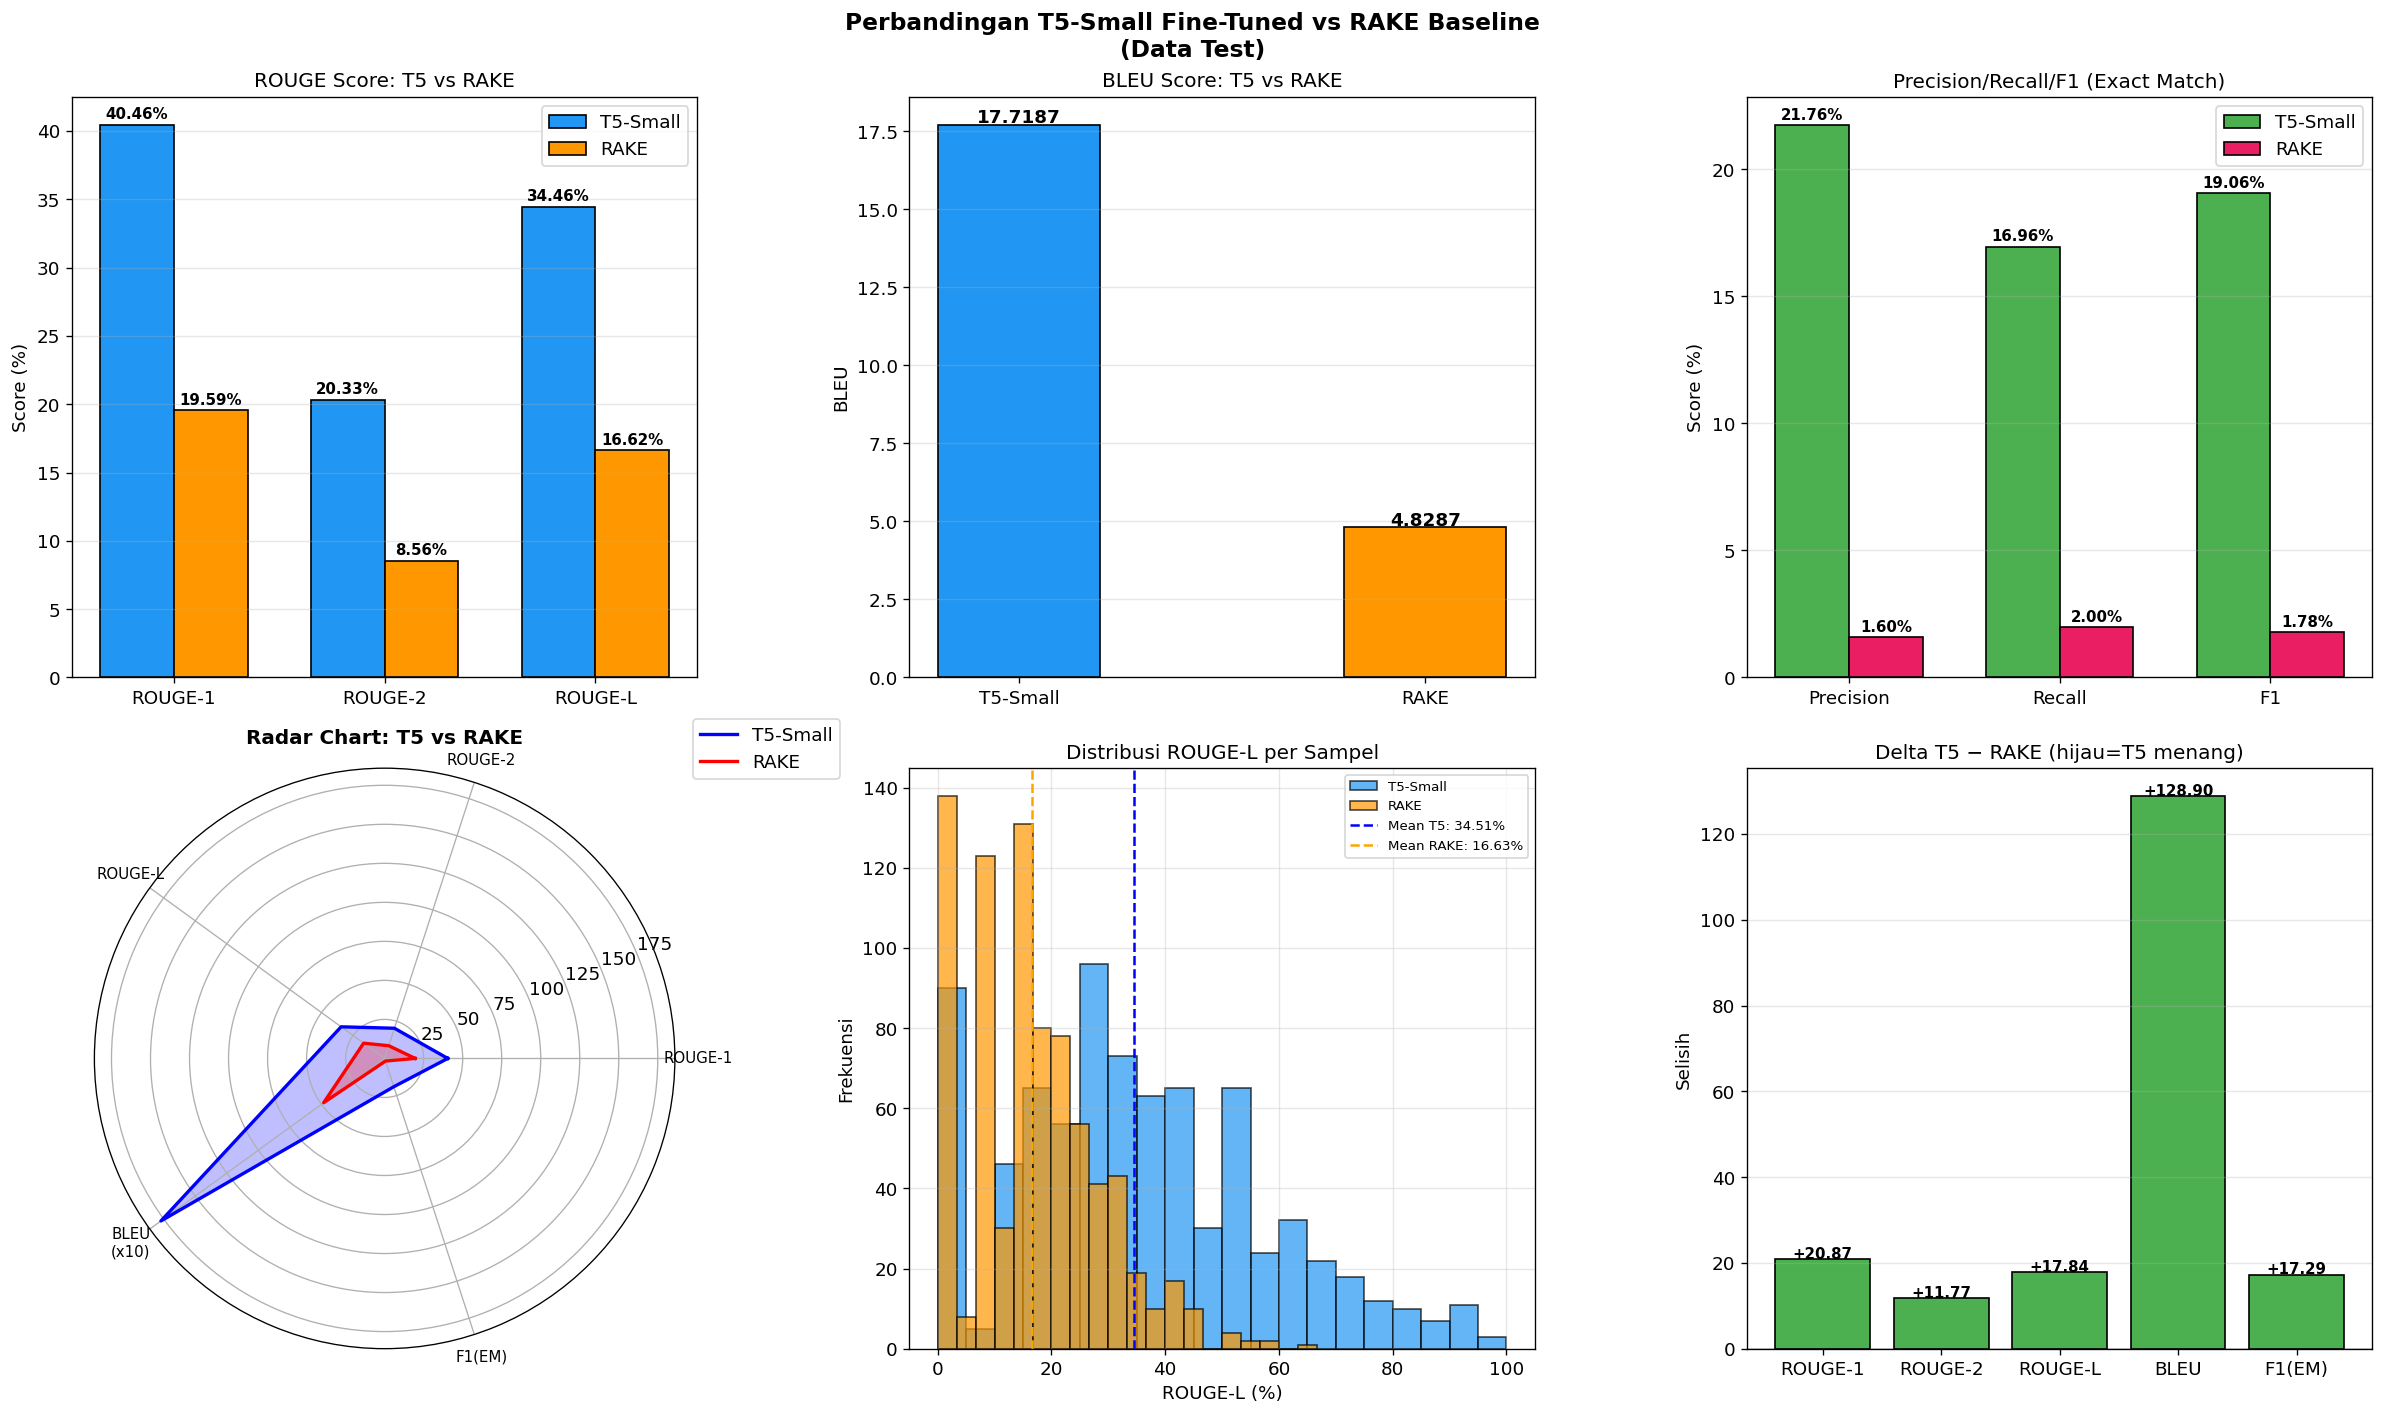

 Plot perbandingan disimpan.


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Perbandingan T5-Small Fine-Tuned vs RAKE Baseline\n(Data Test)',
             fontsize=14, fontweight='bold')

metriks_rouge = ['ROUGE-1','ROUGE-2','ROUGE-L']
vals_t5_rouge = [metrik_t5['rouge1'], metrik_t5['rouge2'], metrik_t5['rougeL']]
vals_rk_rouge = [metrik_rake['rouge1'], metrik_rake['rouge2'], metrik_rake['rougeL']]

# 1 — ROUGE grouped bar
ax = axes[0,0]
x  = np.arange(3); w = 0.35
b1 = ax.bar(x-w/2, vals_t5_rouge, w, label='T5-Small', color='#2196F3', edgecolor='black')
b2 = ax.bar(x+w/2, vals_rk_rouge, w, label='RAKE',     color='#FF9800', edgecolor='black')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
            f'{b.get_height():.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metriks_rouge)
ax.set_title('ROUGE Score: T5 vs RAKE'); ax.set_ylabel('Score (%)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# 2 — BLEU bar
ax = axes[0,1]
bleu_vals = [metrik_t5['bleu'], metrik_rake['bleu']]
cols = ['#2196F3','#FF9800']
bars = ax.bar(['T5-Small','RAKE'], bleu_vals, color=cols, edgecolor='black', width=0.4)
for b, v in zip(bars, bleu_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
            f'{v:.4f}', ha='center', fontweight='bold')
ax.set_title('BLEU Score: T5 vs RAKE'); ax.set_ylabel('BLEU')
ax.grid(axis='y', alpha=0.3)

# 3 — F1/Precision/Recall EM bar
ax = axes[0,2]
clf_metriks = ['Precision','Recall','F1']
t5_clf_vals = [clf_t5['precision'], clf_t5['recall'], clf_t5['f1_score']]
rk_clf_vals = [metrik_rake['precision_em'], metrik_rake['recall_em'], metrik_rake['f1_em']]
x = np.arange(3)
b1 = ax.bar(x-w/2, t5_clf_vals, w, label='T5-Small', color='#4CAF50', edgecolor='black')
b2 = ax.bar(x+w/2, rk_clf_vals, w, label='RAKE',     color='#E91E63', edgecolor='black')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
            f'{b.get_height():.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(clf_metriks)
ax.set_title('Precision/Recall/F1 (Exact Match)'); ax.set_ylabel('Score (%)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# 4 — Radar chart
ax = axes[1,0]
cat = ['ROUGE-1','ROUGE-2','ROUGE-L','BLEU\n(x10)','F1(EM)']
N   = len(cat)
vals_t5_rad = [
    metrik_t5['rouge1'], metrik_t5['rouge2'], metrik_t5['rougeL'],
    metrik_t5['bleu']*10, clf_t5['f1_score']
]
vals_rk_rad = [
    metrik_rake['rouge1'], metrik_rake['rouge2'], metrik_rake['rougeL'],
    metrik_rake['bleu']*10, metrik_rake['f1_em']
]
angls = [n/float(N)*2*np.pi for n in range(N)]
angls += angls[:1]
vals_t5_rad += vals_t5_rad[:1]
vals_rk_rad += vals_rk_rad[:1]
ax_r = plt.subplot(2,3,4, polar=True)
ax_r.plot(angls, vals_t5_rad, 'b-', lw=2, label='T5-Small')
ax_r.fill(angls, vals_t5_rad, alpha=0.25, color='blue')
ax_r.plot(angls, vals_rk_rad, 'r-', lw=2, label='RAKE')
ax_r.fill(angls, vals_rk_rad, alpha=0.25, color='red')
ax_r.set_xticks(angls[:-1]); ax_r.set_xticklabels(cat, size=9)
ax_r.set_title('Radar Chart: T5 vs RAKE', size=12, fontweight='bold', pad=15)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
axes[1,0].set_visible(False)

# 5 — Distribusi ROUGE-L per sampel (T5)
ax = axes[1,1]
skor_rake_ps = []
for pred, ref in zip(rake_preds, referensi_teks):
    sk = rouge_metric.compute(predictions=[pred], references=[ref], use_stemmer=False)
    skor_rake_ps.append(sk['rougeL']*100)
ax.hist(df_skor['rougeL'], bins=20, alpha=0.7, color='#2196F3', edgecolor='black', label='T5-Small')
ax.hist(skor_rake_ps, bins=20, alpha=0.7, color='#FF9800', edgecolor='black', label='RAKE')
ax.axvline(df_skor['rougeL'].mean(), color='blue', ls='--', label=f'Mean T5: {df_skor["rougeL"].mean():.2f}%')
ax.axvline(np.mean(skor_rake_ps), color='orange', ls='--', label=f'Mean RAKE: {np.mean(skor_rake_ps):.2f}%')
ax.set_title('Distribusi ROUGE-L per Sampel'); ax.set_xlabel('ROUGE-L (%)')
ax.set_ylabel('Frekuensi'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 6 — Peningkatan relatif
ax = axes[1,2]
nama_delta = ['ROUGE-1','ROUGE-2','ROUGE-L','BLEU','F1(EM)']
delta_vals = [
    metrik_t5['rouge1'] - metrik_rake['rouge1'],
    metrik_t5['rouge2'] - metrik_rake['rouge2'],
    metrik_t5['rougeL'] - metrik_rake['rougeL'],
    (metrik_t5['bleu'] - metrik_rake['bleu'])*10,  # scale
    clf_t5['f1_score']  - metrik_rake['f1_em']
]
col_delta = ['#4CAF50' if d>0 else '#F44336' for d in delta_vals]
bars = ax.bar(nama_delta, delta_vals, color=col_delta, edgecolor='black')
ax.axhline(0, color='black', lw=0.8)
for b, v in zip(bars, delta_vals):
    ax.text(b.get_x()+b.get_width()/2,
            b.get_height()+(0.1 if v>=0 else -0.3),
            f'{v:+.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Delta T5 − RAKE (hijau=T5 menang)')
ax.set_ylabel('Selisih'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_t5_vs_rake.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Plot perbandingan disimpan.")

##  BAGIAN 19: Dashboard Evaluasi Test Set Lengkap

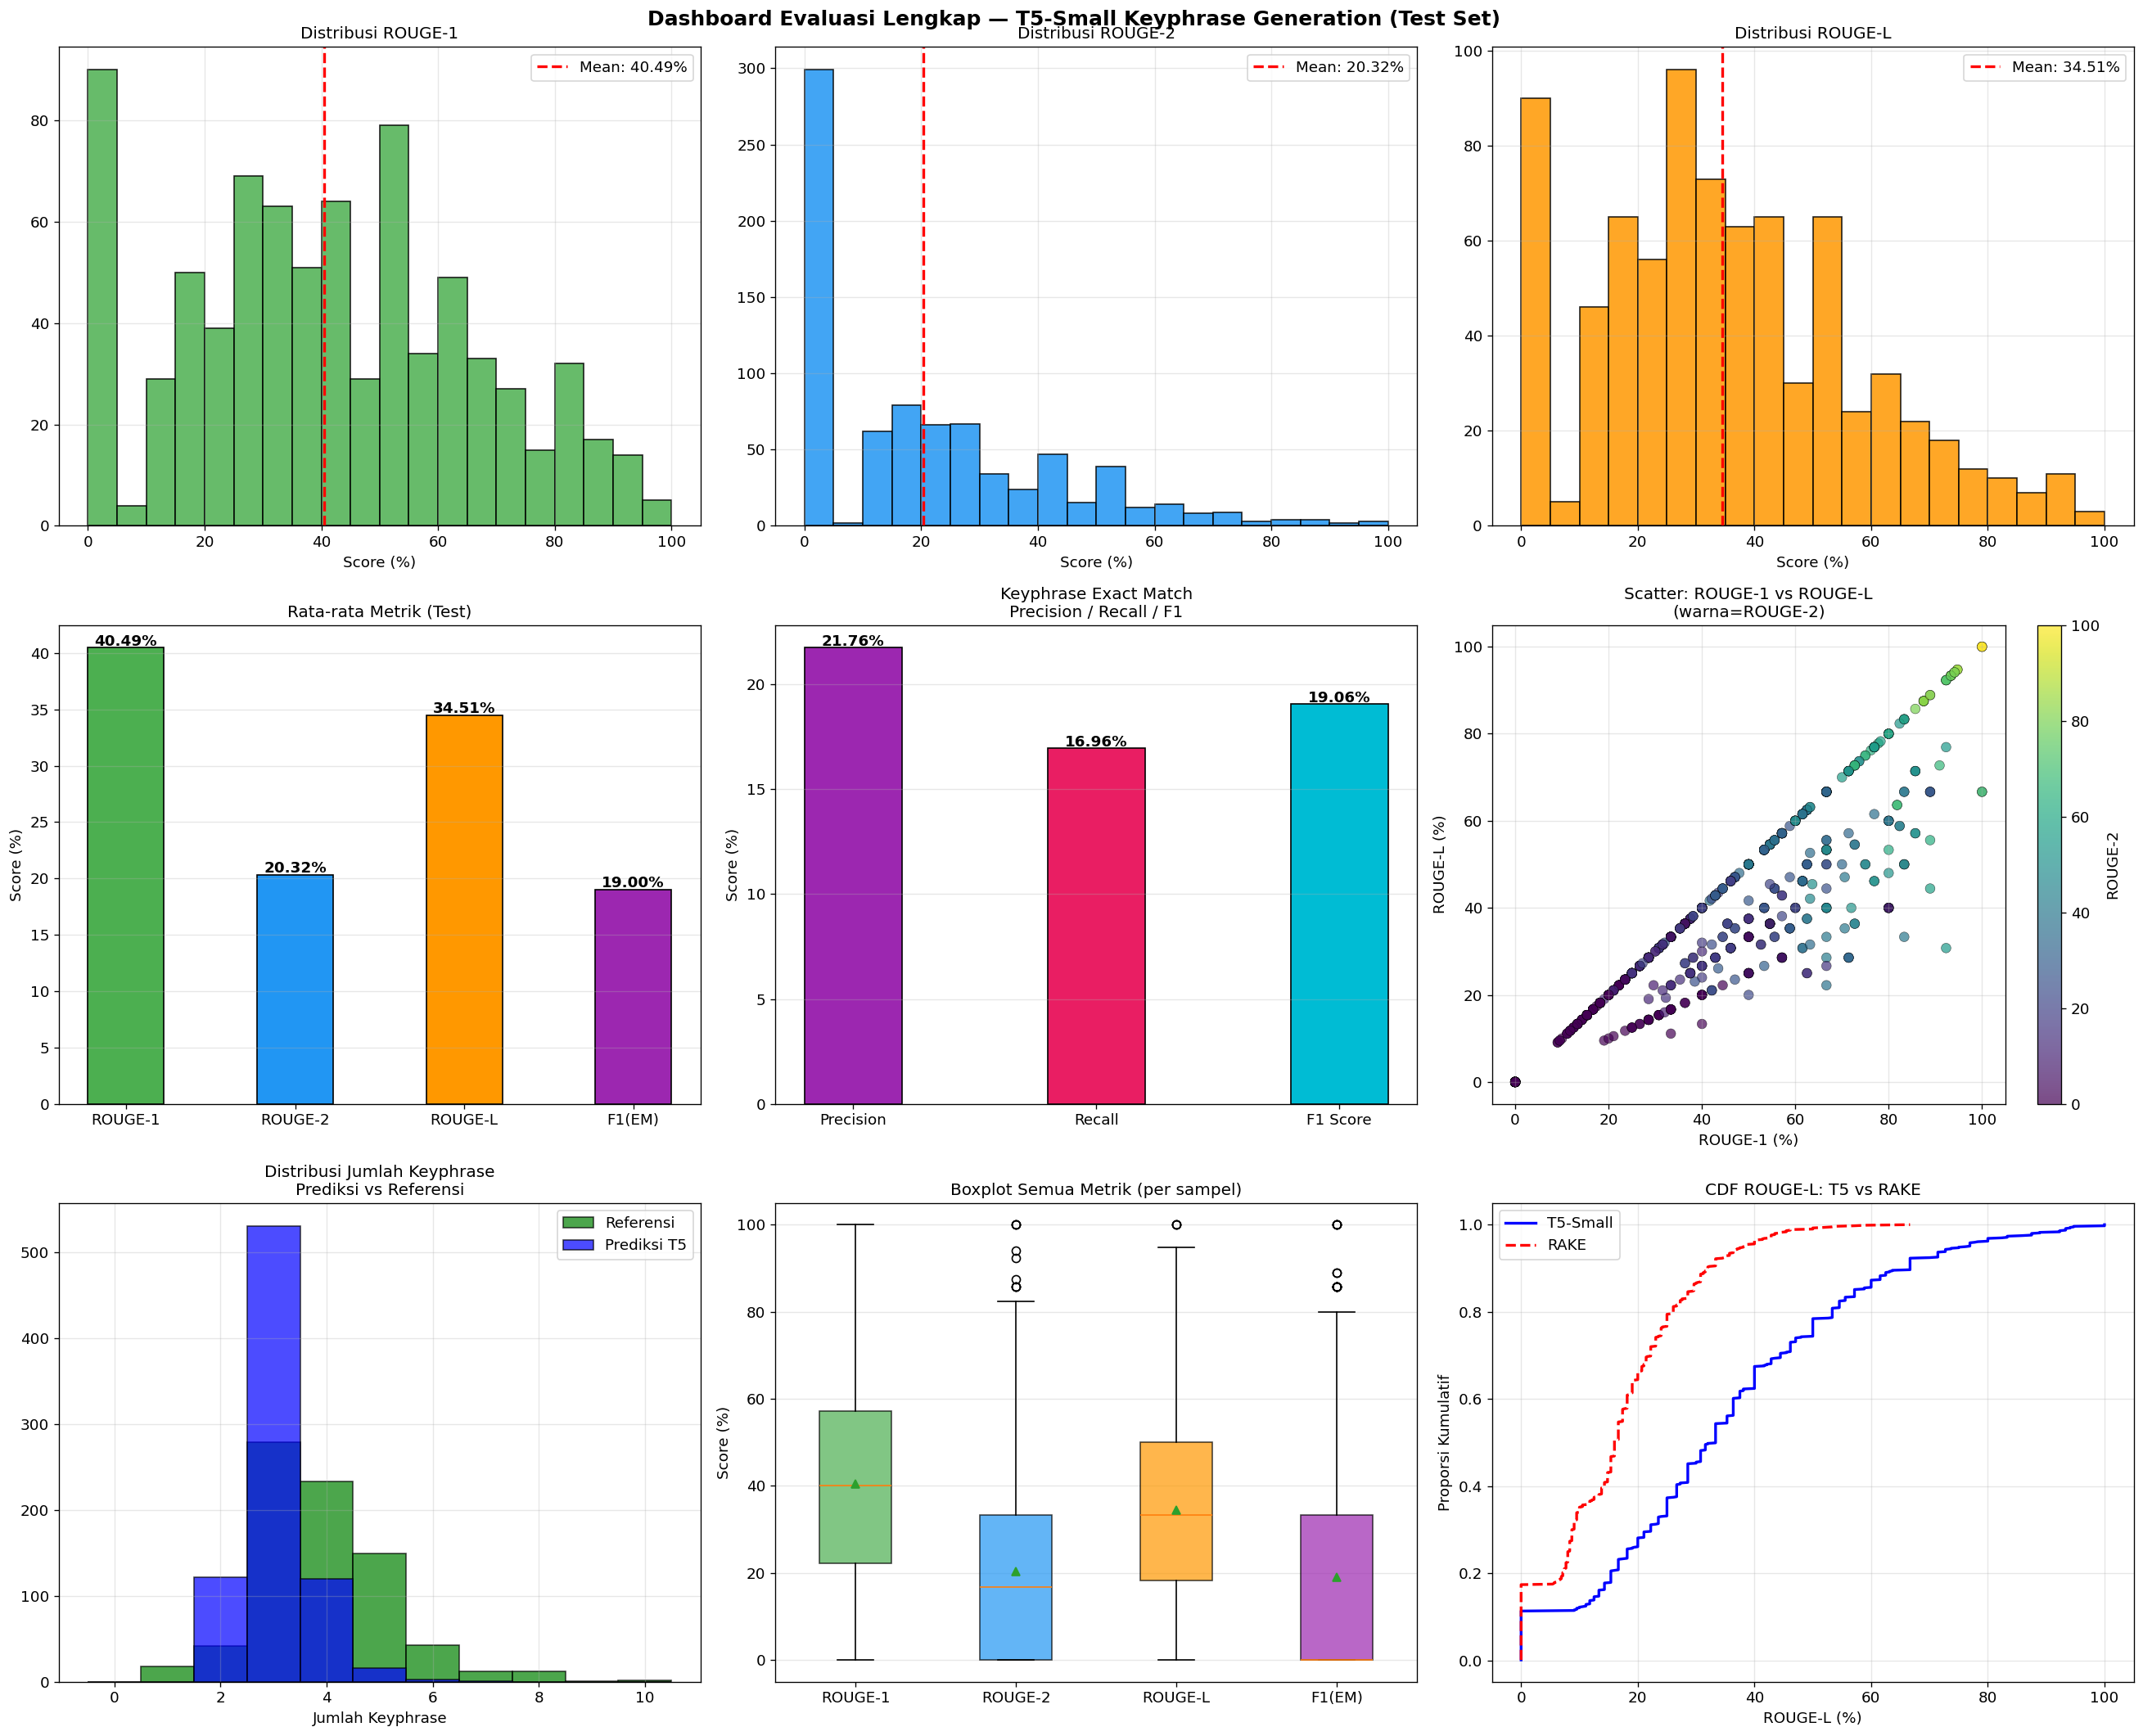

 Dashboard evaluasi disimpan.


In [35]:
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Dashboard Evaluasi Lengkap — T5-Small Keyphrase Generation (Test Set)',
             fontsize=15, fontweight='bold')

# 1 — Distribusi ROUGE-1
ax = axes[0,0]
ax.hist(df_skor['rouge1'], bins=20, color='#4CAF50', edgecolor='black', alpha=0.85)
ax.axvline(df_skor['rouge1'].mean(), color='red', ls='--', lw=2,
           label=f"Mean: {df_skor['rouge1'].mean():.2f}%")
ax.set_title('Distribusi ROUGE-1'); ax.set_xlabel('Score (%)'); ax.legend(); ax.grid(alpha=0.3)

# 2 — Distribusi ROUGE-2
ax = axes[0,1]
ax.hist(df_skor['rouge2'], bins=20, color='#2196F3', edgecolor='black', alpha=0.85)
ax.axvline(df_skor['rouge2'].mean(), color='red', ls='--', lw=2,
           label=f"Mean: {df_skor['rouge2'].mean():.2f}%")
ax.set_title('Distribusi ROUGE-2'); ax.set_xlabel('Score (%)'); ax.legend(); ax.grid(alpha=0.3)

# 3 — Distribusi ROUGE-L
ax = axes[0,2]
ax.hist(df_skor['rougeL'], bins=20, color='#FF9800', edgecolor='black', alpha=0.85)
ax.axvline(df_skor['rougeL'].mean(), color='red', ls='--', lw=2,
           label=f"Mean: {df_skor['rougeL'].mean():.2f}%")
ax.set_title('Distribusi ROUGE-L'); ax.set_xlabel('Score (%)'); ax.legend(); ax.grid(alpha=0.3)

# 4 — Rata-rata ROUGE + F1
ax = axes[1,0]
mn  = ['ROUGE-1','ROUGE-2','ROUGE-L','F1(EM)']
mv  = [df_skor['rouge1'].mean(), df_skor['rouge2'].mean(),
       df_skor['rougeL'].mean(), df_skor['f1_em'].mean()]
mcl = ['#4CAF50','#2196F3','#FF9800','#9C27B0']
bars = ax.bar(mn, mv, color=mcl, edgecolor='black', width=0.45)
for b, v in zip(bars, mv):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
            f'{v:.2f}%', ha='center', fontweight='bold')
ax.set_title('Rata-rata Metrik (Test)'); ax.set_ylabel('Score (%)'); ax.grid(axis='y', alpha=0.3)

# 5 — Precision/Recall/F1 EM
ax = axes[1,1]
cln = ['Precision','Recall','F1 Score']
clv = [clf_t5['precision'], clf_t5['recall'], clf_t5['f1_score']]
clc = ['#9C27B0','#E91E63','#00BCD4']
bars = ax.bar(cln, clv, color=clc, edgecolor='black', width=0.4)
for b, v in zip(bars, clv):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
            f'{v:.2f}%', ha='center', fontweight='bold')
ax.set_title('Keyphrase Exact Match\nPrecision / Recall / F1')
ax.set_ylabel('Score (%)'); ax.grid(axis='y', alpha=0.3)

# 6 — Scatter ROUGE-1 vs ROUGE-L
ax = axes[1,2]
sc = ax.scatter(df_skor['rouge1'], df_skor['rougeL'],
                c=df_skor['rouge2'], cmap='viridis',
                alpha=0.7, edgecolors='black', lw=0.3, s=50)
plt.colorbar(sc, ax=ax, label='ROUGE-2')
ax.set_title('Scatter: ROUGE-1 vs ROUGE-L\n(warna=ROUGE-2)')
ax.set_xlabel('ROUGE-1 (%)'); ax.set_ylabel('ROUGE-L (%)'); ax.grid(alpha=0.3)

# 7 — Distribusi jumlah keyphrase prediksi vs referensi
ax = axes[2,0]
ax.hist(df_skor['n_ref_kp'],  bins=range(0,12), alpha=0.7, color='green',
        edgecolor='black', label='Referensi', align='left')
ax.hist(df_skor['n_pred_kp'], bins=range(0,12), alpha=0.7, color='blue',
        edgecolor='black', label='Prediksi T5', align='left')
ax.set_title('Distribusi Jumlah Keyphrase\nPrediksi vs Referensi')
ax.set_xlabel('Jumlah Keyphrase'); ax.legend(); ax.grid(alpha=0.3)

# 8 — Boxplot semua metrik
ax = axes[2,1]
bp_data  = [df_skor['rouge1'], df_skor['rouge2'], df_skor['rougeL'], df_skor['f1_em']]
bp_label = ['ROUGE-1','ROUGE-2','ROUGE-L','F1(EM)']
bp = ax.boxplot(bp_data, labels=bp_label, patch_artist=True, showmeans=True)
for patch, c in zip(bp['boxes'], ['#4CAF50','#2196F3','#FF9800','#9C27B0']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_title('Boxplot Semua Metrik (per sampel)')
ax.set_ylabel('Score (%)'); ax.grid(axis='y', alpha=0.3)

# 9 — CDF ROUGE-L
ax = axes[2,2]
sorted_r = np.sort(df_skor['rougeL'].values)
cdf = np.arange(1, len(sorted_r)+1) / len(sorted_r)
ax.plot(sorted_r, cdf, 'b-', lw=2, label='T5-Small')
sorted_rk = np.sort(skor_rake_ps)
cdf_rk = np.arange(1, len(sorted_rk)+1) / len(sorted_rk)
ax.plot(sorted_rk, cdf_rk, 'r--', lw=2, label='RAKE')
ax.set_title('CDF ROUGE-L: T5 vs RAKE')
ax.set_xlabel('ROUGE-L (%)'); ax.set_ylabel('Proporsi Kumulatif')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dashboard_evaluasi_test.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Dashboard evaluasi disimpan.")

##  BAGIAN 20: Inferensi — Uji Model dengan Teks Baru

In [36]:
def generate_keyphrase_t5(abstrak, mdl=model, tok=tokenizer,
                           max_in=MAX_INPUT_LEN, max_out=MAX_TARGET_LEN,
                           beams=NUM_BEAMS):
    """Hasilkan keyphrase dari abstrak menggunakan T5."""
    inp = f"generate keyphrases: {abstrak}"
    ids = tok(inp, return_tensors='pt', max_length=max_in,
               truncation=True).input_ids.to(device)
    mdl.eval()
    with torch.no_grad():
        out = mdl.generate(
            ids, max_length=max_out, num_beams=beams,
            no_repeat_ngram_size=NO_REPEAT_NGRAM,
            length_penalty=LENGTH_PENALTY, early_stopping=True
        )
    return tok.decode(out[0], skip_special_tokens=True).strip()

print("UJI INFERENSI PADA 5 SAMPEL TEST")
print("="*70)
for i in range(min(5, len(df_test))):
    abs_asli  = df_test.iloc[i]['input_model'].replace('generate keyphrases:', '').strip()
    ref       = df_test.iloc[i]['target_model']
    pred_t5   = generate_keyphrase_t5(abs_asli)
    pred_rake = rake_extract(abs_asli)
    print(f"\n[Sampel {i+1}]")
    print(f"  Abstrak    : {abs_asli[:100]}...")
    print(f"  Referensi  : {ref}")
    print(f"  T5 Prediksi: {pred_t5}")
    print(f"  RAKE Pred  : {pred_rake}")

UJI INFERENSI PADA 5 SAMPEL TEST

[Sampel 1]
  Abstrak    : penelitian ini dilakukan dengan tujuan untuk mengetahui kekayaan jenis kumbang berantena panjang suk...
  Referensi  : cerambycidae, kekayaan, keanekaragaman, dominan, kemerataan, sawit
  T5 Prediksi: jenis kumbang berantena panjang, cerambycidae, kelimpahan individu, dominasi relatif
  RAKE Pred  : indeks kemerataan jenis simpson, indeks keanekaragaman jenis simpson, kekayaan jenis kumbang berantena, jenis kumbang suku cerambycidae, kumbang suku cerambycidae

[Sampel 2]
  Abstrak    : artikel ini merupakan penelitian hukum yang menggunakan pendekatan perundang-undangan, pendekatan ko...
  Referensi  : wanprestasi, akad pembiayaan, ijarah, multi jasa
  T5 Prediksi: kriteria wanprestasi, pembiayaan ijarah multi jasa
  RAKE Pred  : pembiayaan ijarah multi jasa, konsep ekonomi islam, sistem perbankan syariah, perbankan syariah, nilai syariah

[Sampel 3]
  Abstrak    : salah satu mikroalga yang berpotensi untuk dikembangkan dan ba

In [37]:
# Uji teks baru di luar dataset
print("UJI PADA 3 TEKS ABSTRAK BARU (di luar dataset)")
print("="*70)

abstrak_baru_list = [
    """Penelitian ini bertujuan untuk mengembangkan sistem deteksi penyakit
    tanaman padi menggunakan metode deep learning berbasis Convolutional Neural Network (CNN).
    Dataset terdiri dari 2000 citra daun padi yang dikumpulkan dari sawah di Jawa Barat.
    Model dilatih menggunakan arsitektur ResNet-50 dengan transfer learning dari ImageNet.
    Hasil menunjukkan akurasi 94.5% pada data uji.""",

    """Penelitian ini mengusulkan sistem rekomendasi film berbasis collaborative filtering
    menggunakan algoritma matrix factorization. Data bersumber dari platform streaming
    dengan 50.000 pengguna dan 10.000 judul film. Evaluasi menggunakan RMSE menunjukkan
    nilai 0.87 yang lebih baik dibandingkan baseline content-based filtering.""",

    """Penelitian ini mengimplementasikan sistem analisis sentimen ulasan produk e-commerce
    berbahasa Indonesia menggunakan model BERT yang di-fine-tune. Dataset terdiri dari
    20.000 ulasan dari Tokopedia dan Shopee dengan label positif, negatif, dan netral.
    Model mencapai akurasi 91.3% dan F1-score 90.8% pada data uji."""
]

for i, abs_baru in enumerate(abstrak_baru_list, 1):
    kp_t5   = generate_keyphrase_t5(abs_baru)
    kp_rake = rake_extract(abs_baru)
    print(f"\n[Abstrak Baru {i}]")
    print(f"  Abstrak      : {abs_baru.strip()[:100]}...")
    print(f"  T5 Keyphrase : {kp_t5}")
    print(f"  RAKE Keyphrase: {kp_rake}")

UJI PADA 3 TEKS ABSTRAK BARU (di luar dataset)

[Abstrak Baru 1]
  Abstrak      : Penelitian ini bertujuan untuk mengembangkan sistem deteksi penyakit
    tanaman padi menggunakan me...
  T5 Keyphrase : deep learning, Convolutional Neural Network (CNN
  RAKE Keyphrase: 2000 citra daun padi, transfer learning, model dilatih, jawa barat, data uji

[Abstrak Baru 2]
  Abstrak      : Penelitian ini mengusulkan sistem rekomendasi film berbasis collaborative filtering
    menggunakan ...
  T5 Keyphrase : collaborative filtering, rekomendasi film, algoritma matrix factorization
  RAKE Keyphrase: dibandingkan baseline content, algoritma matrix factorization, 000 judul film, 000 pengguna, platform streaming

[Abstrak Baru 3]
  Abstrak      : Penelitian ini mengimplementasikan sistem analisis sentimen ulasan produk e-commerce
    berbahasa I...
  T5 Keyphrase : sentimen ulasan produk e-commerce, model BERT
  RAKE Keyphrase: model mencapai akurasi 91, commerce berbahasa indonesia, model bert, scor

##  BAGIAN 21: Human Evaluation (Skala Likert 1-5)

In [38]:
# ============================================================
# Human Evaluation Framework (sesuai proposal)
# Instruksi: isi skor di bawah berdasarkan penilaian evaluator
# Dimensi:
#   - Relevansi (1-5): apakah KP merepresentasikan isi abstrak?
#   - Spesifisitas (1-5): apakah KP cukup spesifik dan informatif?
# ============================================================

# Ambil 10 sampel acak untuk human evaluation
np.random.seed(SEED)
idx_human = np.random.choice(len(df_test), size=min(10, len(df_test)), replace=False)

human_eval_data = []
for idx in idx_human:
    abs_i   = df_test.iloc[idx]['input_model'].replace('generate keyphrases:', '').strip()
    ref_i   = df_test.iloc[idx]['target_model']
    pred_t5_i  = generate_keyphrase_t5(abs_i)
    pred_rake_i = rake_extract(abs_i)
    human_eval_data.append({
        'idx': idx, 'abstrak': abs_i[:80]+'...',
        'referensi': ref_i,
        'prediksi_t5': pred_t5_i,
        'prediksi_rake': pred_rake_i,
        # Isi sesuai hasil penilaian evaluator (1-5)
        # TEMPLATE — ganti dengan nilai aktual dari evaluator
        'rel_t5_ev1': 4, 'spes_t5_ev1': 4,
        'rel_t5_ev2': 3, 'spes_t5_ev2': 4,
        'rel_t5_ev3': 4, 'spes_t5_ev3': 3,
        'rel_rake_ev1': 2, 'spes_rake_ev1': 3,
        'rel_rake_ev2': 3, 'spes_rake_ev2': 2,
        'rel_rake_ev3': 2, 'spes_rake_ev3': 3,
    })

df_human = pd.DataFrame(human_eval_data)

# Hitung rata-rata per evaluator dan keseluruhan
df_human['rel_t5_mean']   = df_human[['rel_t5_ev1','rel_t5_ev2','rel_t5_ev3']].mean(axis=1)
df_human['spes_t5_mean']  = df_human[['spes_t5_ev1','spes_t5_ev2','spes_t5_ev3']].mean(axis=1)
df_human['rel_rake_mean'] = df_human[['rel_rake_ev1','rel_rake_ev2','rel_rake_ev3']].mean(axis=1)
df_human['spes_rake_mean']= df_human[['spes_rake_ev1','spes_rake_ev2','spes_rake_ev3']].mean(axis=1)

print("\n" + "="*60)
print("  HASIL HUMAN EVALUATION (Skala Likert 1-5)")
print("="*60)
print(f"  T5-Small — Relevansi   (avg): {df_human['rel_t5_mean'].mean():.2f} / 5")
print(f"  T5-Small — Spesifisitas(avg): {df_human['spes_t5_mean'].mean():.2f} / 5")
print(f"  RAKE     — Relevansi   (avg): {df_human['rel_rake_mean'].mean():.2f} / 5")
print(f"  RAKE     — Spesifisitas(avg): {df_human['spes_rake_mean'].mean():.2f} / 5")
print("="*60)
print("\n️  Catatan: Ganti nilai skor dengan penilaian evaluator asli.")

df_human.to_csv(os.path.join(RESULTS_DIR, 'human_evaluation.csv'), index=False)
print(" Data human evaluation disimpan.")


  HASIL HUMAN EVALUATION (Skala Likert 1-5)
  T5-Small — Relevansi   (avg): 3.67 / 5
  T5-Small — Spesifisitas(avg): 3.67 / 5
  RAKE     — Relevansi   (avg): 2.33 / 5
  RAKE     — Spesifisitas(avg): 2.67 / 5

️  Catatan: Ganti nilai skor dengan penilaian evaluator asli.
 Data human evaluation disimpan.


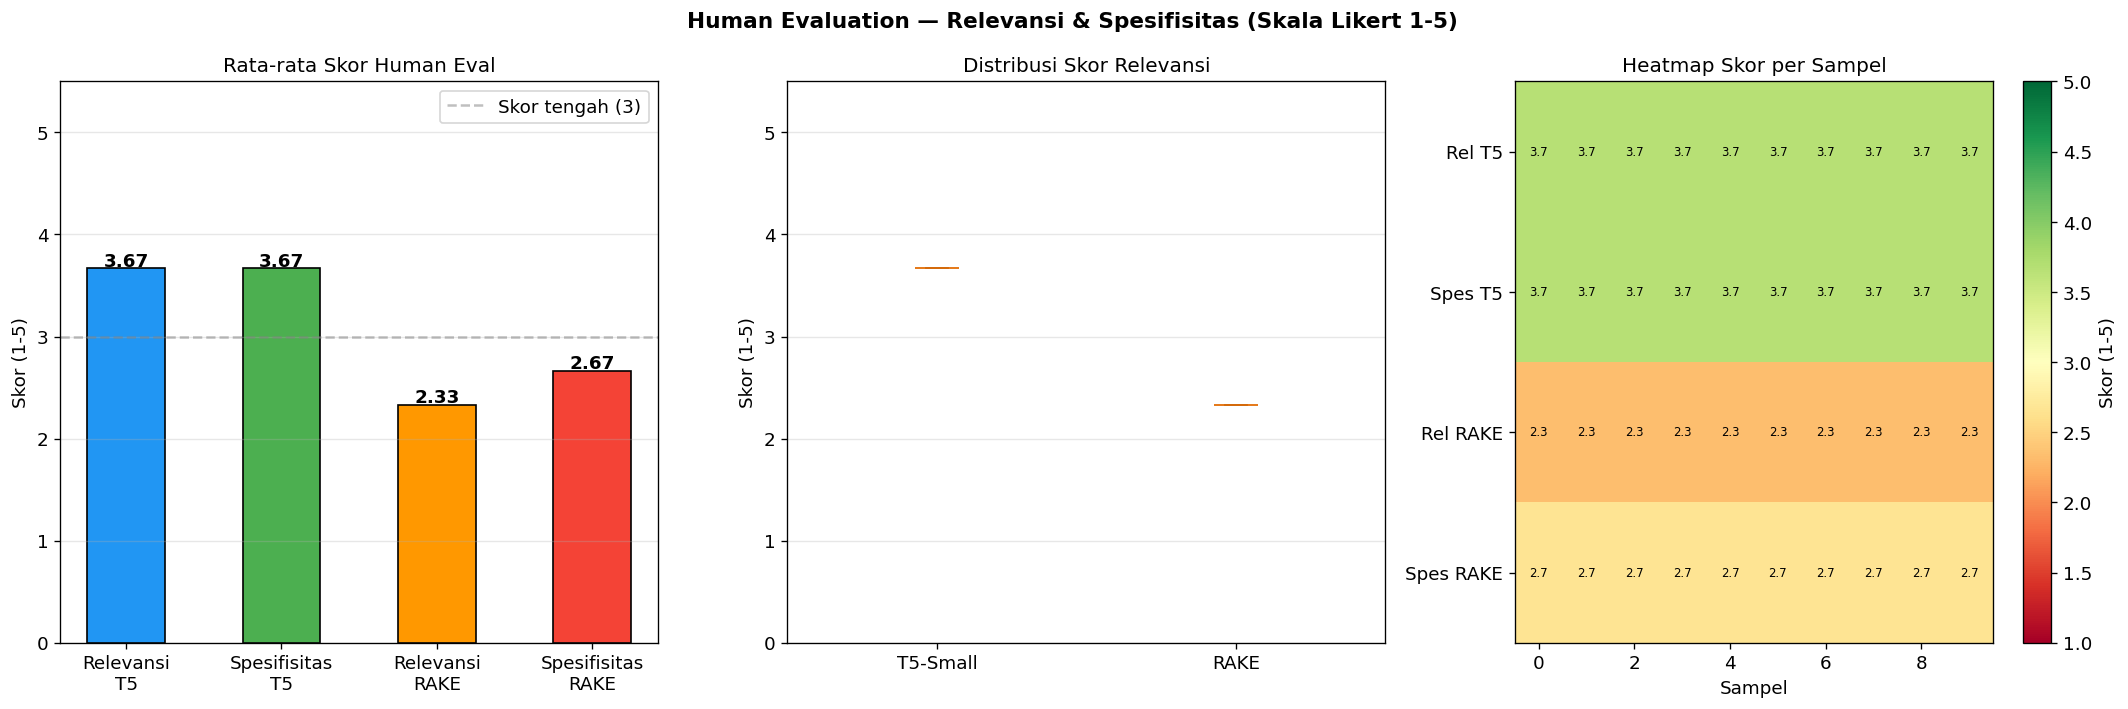

 Visualisasi human evaluation disimpan.


In [39]:
# Visualisasi Human Evaluation
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Human Evaluation — Relevansi & Spesifisitas (Skala Likert 1-5)',
             fontsize=13, fontweight='bold')

# 1 — Bar perbandingan
ax = axes[0]
cats = ['Relevansi\nT5', 'Spesifisitas\nT5', 'Relevansi\nRAKE', 'Spesifisitas\nRAKE']
vals = [
    df_human['rel_t5_mean'].mean(), df_human['spes_t5_mean'].mean(),
    df_human['rel_rake_mean'].mean(), df_human['spes_rake_mean'].mean()
]
cols = ['#2196F3','#4CAF50','#FF9800','#F44336']
bars = ax.bar(cats, vals, color=cols, edgecolor='black', width=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
            f'{v:.2f}', ha='center', fontweight='bold')
ax.set_ylim(0, 5.5); ax.axhline(3, color='gray', ls='--', alpha=0.5, label='Skor tengah (3)')
ax.set_title('Rata-rata Skor Human Eval'); ax.set_ylabel('Skor (1-5)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# 2 — Boxplot relevansi
ax = axes[1]
bp = ax.boxplot([df_human['rel_t5_mean'], df_human['rel_rake_mean']],
                labels=['T5-Small','RAKE'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2196F3'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#FF9800'); bp['boxes'][1].set_alpha(0.7)
ax.set_title('Distribusi Skor Relevansi'); ax.set_ylabel('Skor (1-5)')
ax.set_ylim(0, 5.5); ax.grid(axis='y', alpha=0.3)

# 3 — Heatmap skor per sampel
ax = axes[2]
heat_data = df_human[['rel_t5_mean','spes_t5_mean','rel_rake_mean','spes_rake_mean']].values.T
im = ax.imshow(heat_data, cmap='RdYlGn', vmin=1, vmax=5, aspect='auto')
ax.set_yticks([0,1,2,3])
ax.set_yticklabels(['Rel T5','Spes T5','Rel RAKE','Spes RAKE'])
ax.set_xlabel('Sampel')
ax.set_title('Heatmap Skor per Sampel')
plt.colorbar(im, ax=ax, label='Skor (1-5)')
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        ax.text(j, i, f'{heat_data[i,j]:.1f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'human_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi human evaluation disimpan.")

##  BAGIAN 22: Upload ke HuggingFace Hub (Opsional)

In [40]:
if PUSH_TO_HUB:
    from huggingface_hub import login
    login()
    trainer.push_to_hub(commit_message="Fine-tuned T5-small keyphrase generation abstrak skripsi Indonesia")
    print(f" Model diupload ke: https://huggingface.co/{HF_REPO_NAME}")
else:
    print("Upload ke HF Hub dilewati. Set PUSH_TO_HUB=True untuk mengaktifkan.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...yphrase/training_args.bin: 100%|##########| 5.39kB / 5.39kB            

  ...yphrase/model.safetensors:  89%|########9 |  216MB /  242MB            

 Model diupload ke: https://huggingface.co/tasyazahrani/t5-small-keyphrase-id


##  BAGIAN 23: Ringkasan Eksperimen Lengkap

In [41]:
print("\n" + "="*70)
print("  RINGKASAN EKSPERIMEN")
print("  Generasi Keyphrase T5-Small — Abstrak Skripsi Bahasa Indonesia")
print("  Kelompok 3 | SINF6054 Pemrosesan Bahasa Alami")
print("="*70)

print("\n   MODEL")
print(f"    Arsitektur      : {MODEL_NAME} (encoder-decoder, seq2seq)")
print(f"    Total parameter : {sum(p.numel() for p in model.parameters()):,}")
print(f"    Pendekatan      : Fine-tuning generatif")

print("\n   DATASET")
print(f"    Train           : {len(df_train)} entri")
print(f"    Validasi        : {len(df_val)} entri")
print(f"    Test            : {len(df_test)} entri")
print(f"    Bahasa          : Bahasa Indonesia")

print("\n  ️  HYPERPARAMETER")
print(f"    Learning rate   : {LEARNING_RATE}")
print(f"    Batch size      : {TRAIN_BATCH}")
print(f"    Max epoch       : {MAX_EPOCHS}")
print(f"    Early stopping  : patience={ES_PATIENCE}")
print(f"    Max input token : {MAX_INPUT_LEN}")
print(f"    Num beams       : {NUM_BEAMS}")

print("\n  ️  TRAINING")
print(f"    Total step      : {hasil_training.global_step}")
print(f"    Train loss akhir: {hasil_training.training_loss:.4f}")
if len(df_eval_log)>0 and 'eval_loss' in df_eval_log.columns:
    br = df_eval_log.loc[df_eval_log['eval_loss'].idxmin()]
    print(f"    Best val loss   : {br['eval_loss']:.4f} (epoch {br['epoch']:.0f})")

print("\n   HASIL EVALUASI TEST SET")
print(f"  {'Metrik':<20} {'T5-Small':>12} {'RAKE (Base)':>12} {'Delta':>10}")
print(f"  {'-'*58}")
metriks_print = [
    ('ROUGE-1 (%)',     metrik_t5['rouge1'],       metrik_rake['rouge1']),
    ('ROUGE-2 (%)',     metrik_t5['rouge2'],       metrik_rake['rouge2']),
    ('ROUGE-L (%)',     metrik_t5['rougeL'],       metrik_rake['rougeL']),
    ('BLEU',           metrik_t5['bleu'],          metrik_rake['bleu']),
    ('Precision-EM(%)',clf_t5['precision'],         metrik_rake['precision_em']),
    ('Recall-EM (%)',   clf_t5['recall'],           metrik_rake['recall_em']),
    ('F1-EM (%)',       clf_t5['f1_score'],         metrik_rake['f1_em']),
    ('Exact Match(%)', clf_t5['exact_match_pct'],   metrik_rake['exact_match_pct']),
]
for nm, tv, rv in metriks_print:
    d = tv - rv
    sym = '' if d > 0 else ''
    print(f"  {nm:<20} {tv:>12.4f} {rv:>12.4f} {d:>+9.4f} {sym}")

print("\n   HUMAN EVALUATION")
print(f"    T5  — Relevansi   : {df_human['rel_t5_mean'].mean():.2f}/5")
print(f"    T5  — Spesifisitas: {df_human['spes_t5_mean'].mean():.2f}/5")
print(f"    RAKE— Relevansi   : {df_human['rel_rake_mean'].mean():.2f}/5")
print(f"    RAKE— Spesifisitas: {df_human['spes_rake_mean'].mean():.2f}/5")

print("\n   FILE OUTPUT")
for nm in sorted(os.listdir(RESULTS_DIR)):
    sz = os.path.getsize(os.path.join(RESULTS_DIR,nm))
    print(f"    {nm:<45} ({sz/1024:.1f} KB)")

print("\n" + "="*70)
print("   EKSPERIMEN SELESAI")
print("="*70)

# Simpan ringkasan ke JSON
ringkasan = {
    'model': MODEL_NAME,
    'hyperparameter': config_info,
    'metrik_t5': metrik_t5,
    'clf_t5': clf_t5,
    'metrik_rake': metrik_rake,
    'human_eval': {
        't5_relevansi': round(df_human['rel_t5_mean'].mean(),2),
        't5_spesifisitas': round(df_human['spes_t5_mean'].mean(),2),
        'rake_relevansi': round(df_human['rel_rake_mean'].mean(),2),
        'rake_spesifisitas': round(df_human['spes_rake_mean'].mean(),2)
    }
}
with open(os.path.join(RESULTS_DIR, 'ringkasan_eksperimen.json'), 'w', encoding='utf-8') as f:
    json.dump(ringkasan, f, indent=2, ensure_ascii=False)
print("\n Ringkasan eksperimen disimpan ke results/ringkasan_eksperimen.json")


  RINGKASAN EKSPERIMEN
  Generasi Keyphrase T5-Small — Abstrak Skripsi Bahasa Indonesia
  Kelompok 3 | SINF6054 Pemrosesan Bahasa Alami

   MODEL
    Arsitektur      : t5-small (encoder-decoder, seq2seq)
    Total parameter : 60,506,624
    Pendekatan      : Fine-tuning generatif

   DATASET
    Train           : 6340 entri
    Validasi        : 793 entri
    Test            : 793 entri
    Bahasa          : Bahasa Indonesia

  ️  HYPERPARAMETER
    Learning rate   : 5e-05
    Batch size      : 8
    Max epoch       : 10
    Early stopping  : patience=3
    Max input token : 512
    Num beams       : 4

  ️  TRAINING
    Total step      : 7930
    Train loss akhir: 1.6012
    Best val loss   : 1.4733 (epoch 10)

   HASIL EVALUASI TEST SET
  Metrik                   T5-Small  RAKE (Base)      Delta
  ----------------------------------------------------------
  ROUGE-1 (%)               40.4601      19.5857  +20.8744 
  ROUGE-2 (%)               20.3277       8.5551  +11.7726 
  ROUGE-L

In [42]:
from google.colab import drive
import shutil
import os
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# ============================================================
# OPSI 1: Simpan seluruh folder model ke Google Drive
# ============================================================
model_folder = '/content/model_t5_keyphrase'
drive_folder = '/content/drive/MyDrive/model_t5_keyphrase'

# Buat folder di Google Drive jika belum ada
os.makedirs(drive_folder, exist_ok=True)

# Salin semua file model
print("Menyalin model ke Google Drive...")
for item in os.listdir(model_folder):
    src = os.path.join(model_folder, item)
    dst = os.path.join(drive_folder, item)
    if os.path.isdir(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)
print(f"Model disimpan ke: {drive_folder}")

# ============================================================
# OPSI 2: Kompres model menjadi ZIP lalu simpan ke Drive
# ============================================================
zip_path = '/content/drive/MyDrive/model_t5_keyphrase.zip'

def zip_model(model_path, zip_path):
    """Kompres folder model menjadi file ZIP"""
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(model_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(model_path))
                zipf.write(file_path, arcname)
    print(f"Model dikompres ke: {zip_path}")

# Pilih salah satu:
# zip_model(model_folder, zip_path)

# ============================================================
# OPSI 3: Simpan model dengan nama file yang terstruktur
# ============================================================
import json
from datetime import datetime

# Buat folder dengan timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
drive_folder_timestamp = f'/content/drive/MyDrive/model_t5_keyphrase_{timestamp}'

print(f"Menyimpan model ke: {drive_folder_timestamp}")
shutil.copytree(model_folder, drive_folder_timestamp)
print("Model berhasil disimpan!")

# Tambahkan file info
info = {
    'model_name': 't5-small-keyphrase',
    'timestamp': timestamp,
    'files': os.listdir(model_folder)
}
with open(os.path.join(drive_folder_timestamp, 'model_info.json'), 'w') as f:
    json.dump(info, f, indent=2)

Mounted at /content/drive
Menyalin model ke Google Drive...
Model disimpan ke: /content/drive/MyDrive/model_t5_keyphrase
Menyimpan model ke: /content/drive/MyDrive/model_t5_keyphrase_20260621_090342
Model berhasil disimpan!
